In [384]:
# Suppress warning messages to keep the output clean
import warnings
warnings.filterwarnings("ignore")

# Import essential libraries for data handling and analysis
import numpy as np                  # For numerical operations
import pandas as pd                # For working with dataframes and data manipulation
#import yfinance as yf              # For downloading historical market data

# Import technical analysis indicators from the 'ta' library
from ta.momentum import RSIIndicator           # Relative Strength Index for momentum analysis
from ta.trend import MACD                      # Moving Average Convergence Divergence for trend detection
from ta.volatility import BollingerBands       # Bollinger Bands for measuring price volatility
from ta.volatility import AverageTrueRange     # Average True Range for measuring market volatility
from ta.trend import SMAIndicator              # Simple Moving Average for trend smoothing


In [385]:
from twelvedata import TDClient

td = "d6ccf0d1458441bda227ea6a01e2ac08"

In [386]:
def fetch_forex_data(symbol: str, interval: str = "1day", outputsize: int = 5000, apikey: str = td) -> pd.DataFrame:
    try:
        # Initialize client
        td = TDClient(apikey=apikey)

        # Fetch data
        ts = td.time_series(
            symbol=symbol,
            interval=interval,
            outputsize=outputsize,
            timezone="UTC"
        ).as_pandas()

        if ts is None or ts.empty:
            raise ValueError(f"No data returned for symbol: {symbol}")

        # Reset index if needed
        ts = ts.rename_axis("Date").reset_index()

        # Ensure required columns are available
        required_cols = ['Date', 'open', 'high', 'low', 'close']
        missing = [col for col in required_cols if col not in ts.columns]
        if missing:
            raise KeyError(f"Missing expected columns: {missing}")

        # Clean and standardize column names
        df = ts[required_cols].copy()
        df.columns = ['Date', 'Open', 'High', 'Low', 'Close']
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)

        # Add dummy Volume column if needed
        df['Volume'] = 0

        return df

    except Exception as e:
        print(f"❌ Error fetching data for {symbol}: {e}")
        return pd.DataFrame()  # Return empty DataFrame on error

In [387]:
df_org = fetch_forex_data("EUR/GBP", apikey=td)
df_org.to_csv("fx.csv", index=False)
if df_org.empty:
    print("Data fetch failed.")
else:
    print(df_org.head())
df = df_org.copy()

        Date    Open    High     Low   Close  Volume
0 2006-07-25  0.6822  0.6845  0.6818  0.6837       0
1 2006-07-26  0.6835  0.6863  0.6822  0.6857       0
2 2006-07-27  0.6856  0.6865  0.6821  0.6835       0
3 2006-07-28  0.6830  0.6852  0.6812  0.6846       0
4 2006-07-31  0.6852  0.6855  0.6823  0.6835       0


In [388]:
# Downloading historical daily price data for the EUR/GBP currency pair from Yahoo Finance
#df = yf.download('EURUSD=X', interval='1d', period='30y', progress=False)

# Reset the DataFrame index to convert the 'Date' index into a regular column
#df.reset_index(inplace=True)


In [389]:
# Checking if the downloaded DataFrame is empty (i.e., no data was returned)
if df.empty:
    raise ValueError("No data returned from Yahoo Finance. Try a shorter period or check your internet.")

In [390]:
# PREPRPOCESSING

In [391]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    # Keep essential columns
    df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.dropna(inplace=True)

    # === Engineered Candle Features ===
    df['Candle_Size'] = (df['Close'] - df['Open']).abs()

    # Prevent division by zero
    df['Range'] = (df['High'] - df['Low']).replace(0, 1e-6)

    df['Upper_Wick_Ratio'] = (df['High'] - df[['Open', 'Close']].max(axis=1)) / df['Range']
    df['Lower_Wick_Ratio'] = (df[['Open', 'Close']].min(axis=1) - df['Low']) / df['Range']

    df['Body_to_Range'] = (df['Open'] - df['Close']).abs() / df['Range']

    # Drop temporary helper column
    df.drop(columns=['Range'], inplace=True)

    # Forward-fill and final NA cleanup
    df.ffill(inplace=True)
    df.fillna(0, inplace=True)

    return df


In [392]:
df = preprocess_data(df)

In [393]:
df.head()

,Date,Open,High,Low,Close,Volume,Candle_Size,Upper_Wick_Ratio,Lower_Wick_Ratio,Body_to_Range
0,2006-07-25,0.6822,0.6845,0.6818,0.6837,0,0.0015,0.296296,0.148148,0.555556
1,2006-07-26,0.6835,0.6863,0.6822,0.6857,0,0.0022,0.146341,0.317073,0.536585
2,2006-07-27,0.6856,0.6865,0.6821,0.6835,0,0.0021,0.204545,0.318182,0.477273
3,2006-07-28,0.6830,0.6852,0.6812,0.6846,0,0.0016,0.150000,0.450000,0.400000
4,2006-07-31,0.6852,0.6855,0.6823,0.6835,0,0.0017,0.093750,0.375000,0.531250


In [394]:
# Extract and add new time-based features to the DataFrame
df['dayofweek'] = df['Date'].dt.dayofweek   # Day of the week (0=Monday, 6=Sunday)
df['month'] = df['Date'].dt.month           # Month of the year (1=January, 12=December)

In [395]:
# Creating separate pandas Series for High, Low, and Close prices
# This makes it easier to pass them into technical indicator functions
high_series = pd.Series(df['High'].values.flatten(), index=df.index)
low_series = pd.Series(df['Low'].values.flatten(), index=df.index)
close_series = pd.Series(df['Close'].values.flatten(), index=df.index)

In [396]:
# Calculateing the logarithmic return of the closing price
# This measures the percentage change in price on a logarithmic scale
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

In [397]:
# === Technical Indicators Calculation ===

# Calculate 14-period Relative Strength Index (RSI) for momentum analysis
df['RSI'] = RSIIndicator(close=close_series, window=14).rsi()

# Calculate Moving Average Convergence Divergence (MACD) indicators
macd = MACD(close=close_series)
df['MACD'] = macd.macd()                      # MACD line
df['MACD_signal'] = macd.macd_signal()        # Signal line
df['MACD_diff'] = macd.macd_diff()            # MACD histogram (difference between MACD and Signal line)

# Calculate Bollinger Bands for volatility analysis
bb = BollingerBands(close=close_series)
df['BB_upper'] = bb.bollinger_hband()         # Upper Bollinger Band
df['BB_lower'] = bb.bollinger_lband()         # Lower Bollinger Band
df['BB_width'] = df['BB_upper'] - df['BB_lower']  # Band width as a volatility metric

# Calculate Simple Moving Averages (SMAs) for different periods
df['SMA_10'] = SMAIndicator(close=close_series, window=10).sma_indicator()
df['SMA_20'] = SMAIndicator(close=close_series, window=20).sma_indicator()
df['SMA_50'] = SMAIndicator(close=close_series, window=50).sma_indicator()
df['SMA_100'] = SMAIndicator(close=close_series, window=100).sma_indicator()

# Calculate Average True Range (ATR) to measure market volatility
atr = AverageTrueRange(high=high_series, low=low_series, close=close_series, window=14)
df['ATR'] = atr.average_true_range()


In [398]:
print(type(df['Close']), df['Close'].shape)

<class 'pandas.core.series.Series'> (5000,)


In [399]:
df.tail()

,Date,Open,High,Low,Close,Volume,Candle_Size,Upper_Wick_Ratio,Lower_Wick_Ratio,Body_to_Range,...,MACD_signal,MACD_diff,BB_upper,BB_lower,BB_width,SMA_10,SMA_20,SMA_50,SMA_100,ATR
4995,2025-07-10,0.86243,0.86340,0.86096,0.86170,0,0.00073,0.397541,0.303279,0.299180,...,0.003602,0.000082,0.866159,0.849666,0.016493,0.861588,0.857913,0.849222,0.848701,0.003457
4996,2025-07-11,0.86171,0.86670,0.86086,0.86624,0,0.00453,0.078767,0.145548,0.775685,...,0.003661,0.000235,0.867357,0.849595,0.017762,0.862409,0.858476,0.849704,0.848957,0.003627
4997,2025-07-12,0.86621,0.86653,0.86621,0.86653,0,0.00032,0.000000,0.000000,1.000000,...,0.003737,0.000304,0.868354,0.849906,0.018448,0.863202,0.859130,0.850225,0.849205,0.003391
4998,2025-07-14,0.86498,0.86928,0.86488,0.86853,0,0.00355,0.170455,0.022727,0.806818,...,0.003843,0.000425,0.869727,0.849738,0.019989,0.863539,0.859733,0.850790,0.849505,0.003463
4999,2025-07-15,0.86853,0.86961,0.86689,0.86705,0,0.00148,0.397059,0.058824,0.544118,...,0.003930,0.000349,0.870625,0.849887,0.020738,0.864153,0.860256,0.851316,0.849804,0.003410


In [400]:
# Flatten column names in case any are multi-index tuples (e.g., from groupby or merge operations)
# This ensures all column names are simple strings
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

In [401]:
# Checking for missing (NaN) values in each column and display the total count per column
missing = df.isnull().sum()
missing

Date                 0
Open                 0
High                 0
Low                  0
Close                0
Volume               0
Candle_Size          0
Upper_Wick_Ratio     0
Lower_Wick_Ratio     0
Body_to_Range        0
dayofweek            0
month                0
Log_Return           1
RSI                 13
MACD                25
MACD_signal         33
MACD_diff           33
BB_upper            19
BB_lower            19
BB_width            19
SMA_10               9
SMA_20              19
SMA_50              49
SMA_100             99
ATR                  0
dtype: int64

In [402]:
# Remove rows with incomplete indicator values
df.dropna(inplace=True)

In [403]:
df.head()

,Date,Open,High,Low,Close,Volume,Candle_Size,Upper_Wick_Ratio,Lower_Wick_Ratio,Body_to_Range,...,MACD_signal,MACD_diff,BB_upper,BB_lower,BB_width,SMA_10,SMA_20,SMA_50,SMA_100,ATR
99,2006-12-11,0.6749,0.6772,0.6742,0.6766,0,0.0017,0.200000,0.233333,0.566667,...,0.000680,-0.000028,0.678840,0.673160,0.005681,0.67522,0.676000,0.673554,0.675091,0.003077
100,2006-12-12,0.6762,0.6766,0.6726,0.6738,0,0.0024,0.100000,0.300000,0.600000,...,0.000637,-0.000173,0.678905,0.672915,0.005991,0.67499,0.675910,0.673542,0.674992,0.003143
101,2006-12-13,0.6737,0.6745,0.6710,0.6718,0,0.0019,0.228571,0.228571,0.542857,...,0.000540,-0.000388,0.678700,0.672400,0.006300,0.67459,0.675550,0.673498,0.674853,0.003168
102,2006-12-14,0.6717,0.6731,0.6699,0.6703,0,0.0014,0.437500,0.125000,0.437500,...,0.000389,-0.000603,0.678935,0.671435,0.007500,0.67424,0.675185,0.673396,0.674721,0.003171
103,2006-12-15,0.6703,0.6726,0.6689,0.6705,0,0.0002,0.567568,0.378378,0.054054,...,0.000215,-0.000697,0.679071,0.670679,0.008392,0.67393,0.674875,0.673330,0.674580,0.003208


In [404]:
# EXPLOITATIVE DATA ANALYSIS

In [405]:
df.describe()

,Date,Open,High,Low,Close,Volume,Candle_Size,Upper_Wick_Ratio,Lower_Wick_Ratio,Body_to_Range,...,MACD_signal,MACD_diff,BB_upper,BB_lower,BB_width,SMA_10,SMA_20,SMA_50,SMA_100,ATR
count,4901,4901.000000,4901.000000,4901.000000,4901.000000,4901.0,4901.000000,4901.000000,4901.000000,4901.000000,...,4901.000000,4901.000000,4901.000000,4901.000000,4901.000000,4901.000000,4901.000000,4901.000000,4901.000000,4901.000000
mean,2016-04-28 19:27:02.607631104,0.836682,0.840166,0.833541,0.836768,0.0,0.003011,0.309377,0.270895,0.417892,...,0.000257,0.000003,0.849039,0.823770,0.025269,0.836593,0.836404,0.835856,0.834970,0.006643
min,2006-12-11 00:00:00,0.655100,0.657300,0.653400,0.655200,0.0,0.000000,0.000000,-0.067797,0.000000,...,-0.009344,-0.011458,0.663388,0.649336,0.003399,0.657560,0.659150,0.666296,0.669750,0.002192
25%,2011-08-22 00:00:00,0.814600,0.817500,0.811900,0.814800,0.0,0.000970,0.162162,0.128205,0.209677,...,-0.002117,-0.000725,0.825944,0.802332,0.015507,0.814820,0.813710,0.812392,0.814177,0.004911
50%,2016-05-02 00:00:00,0.852800,0.855700,0.850000,0.852800,0.0,0.002200,0.275000,0.235294,0.418605,...,-0.000274,-0.000005,0.862743,0.839789,0.021278,0.852730,0.852286,0.853260,0.853693,0.006302
75%,2021-01-11 00:00:00,0.875600,0.879350,0.871900,0.875500,0.0,0.004100,0.432099,0.385246,0.606557,...,0.002228,0.000736,0.888595,0.862067,0.030109,0.875780,0.876425,0.876060,0.875422,0.007906
max,2025-07-15 00:00:00,0.975800,0.980500,0.965200,0.974700,0.0,0.047100,0.946809,0.965437,1.044248,...,0.029232,0.007074,0.995309,0.907385,0.154473,0.956110,0.934970,0.915374,0.910732,0.020018
std,NaN,0.058482,0.058853,0.058109,0.058347,0.0,0.002974,0.187618,0.180128,0.241279,...,0.004101,0.001403,0.060164,0.057528,0.016534,0.058293,0.058277,0.058326,0.058505,0.002652


In [406]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4901 entries, 99 to 4999
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              4901 non-null   datetime64[ns]
 1   Open              4901 non-null   float64       
 2   High              4901 non-null   float64       
 3   Low               4901 non-null   float64       
 4   Close             4901 non-null   float64       
 5   Volume            4901 non-null   int64         
 6   Candle_Size       4901 non-null   float64       
 7   Upper_Wick_Ratio  4901 non-null   float64       
 8   Lower_Wick_Ratio  4901 non-null   float64       
 9   Body_to_Range     4901 non-null   float64       
 10  dayofweek         4901 non-null   int32         
 11  month             4901 non-null   int32         
 12  Log_Return        4901 non-null   float64       
 13  RSI               4901 non-null   float64       
 14  MACD              4901 non-n

In [407]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Defining a function to plot MACD and RSI indicators for the DataFrame
def plot_macd_rsi(df, title="Indicators"):
    # Create a figure with two subplots: one for MACD, one for RSI
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # === MACD Plot ===
    ax1.plot(df['Date'], df['MACD'], label='MACD', color='blue')              # Plot MACD line
    ax1.plot(df['Date'], df['MACD_signal'], label='Signal', color='orange')   # Plot Signal line
    ax1.bar(df['Date'], df['MACD_diff'], label='MACD Diff', color='gray', alpha=0.5)  # Plot MACD histogram
    ax1.set_title(f"{title} - MACD")
    ax1.legend()
    ax1.grid(True)

    # === RSI Plot ===
    ax2.plot(df['Date'], df['RSI'], label='RSI', color='green')               # Plot RSI line
    ax2.axhline(70, color='red', linestyle='--', label='Overbought')          # Overbought threshold
    ax2.axhline(30, color='blue', linestyle='--', label='Oversold')           # Oversold threshold
    ax2.set_title(f"{title} - RSI")
    ax2.set_ylim(0, 100)
    ax2.legend()
    ax2.grid(True)

    # Optimize layout and display the plot
    plt.tight_layout()
    plt.show()

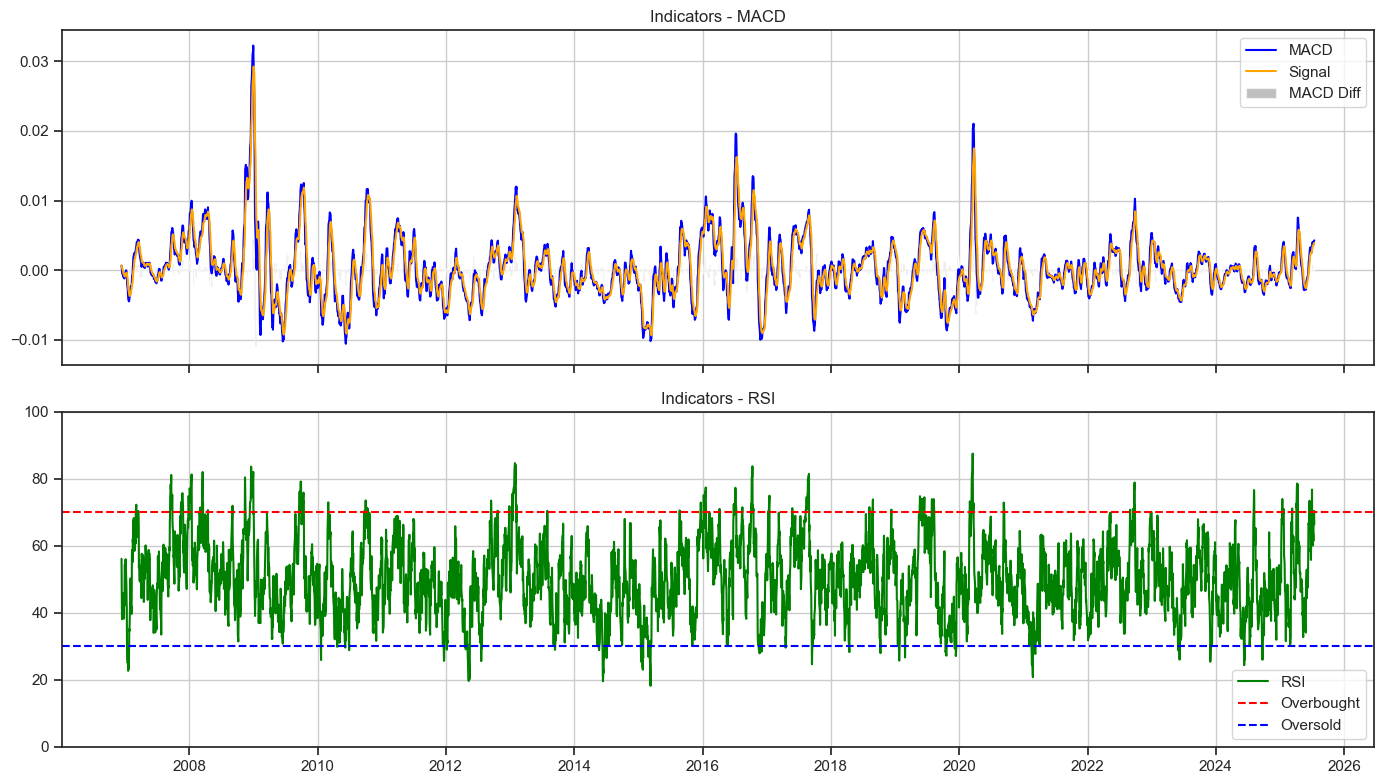

In [408]:
plot_macd_rsi(df)

In [409]:
# Import date formatting tools for better x-axis handling in plots
import matplotlib.dates as mdates

# Define a function to plot Close Price with Bollinger Bands, MACD, and formatted x-axis
def plot_bb_macd_chart(df, title="Technical Analysis"):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])  # Ensure 'Date' is in datetime format for plotting

    # Set up a 3-row subplot layout with custom height ratios
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1.5, 1], hspace=0.3)

    # === 1. Close Price with Bollinger Bands ===
    ax0 = fig.add_subplot(gs[0])
    ax0.plot(df['Date'], df['Close'], label='Close Price', color='black')            # Plot closing price
    ax0.plot(df['Date'], df['BB_upper'], label='BB Upper', color='red', linestyle='--')  # Upper Bollinger Band
    ax0.plot(df['Date'], df['BB_lower'], label='BB Lower', color='blue', linestyle='--') # Lower Bollinger Band
    ax0.fill_between(df['Date'], df['BB_upper'], df['BB_lower'], color='gray', alpha=0.1) # Shaded BB area
    ax0.set_title(f"{title} - Price & Bollinger Bands")
    ax0.legend()
    ax0.grid(True)

    # === 2. MACD Plot ===
    ax1 = fig.add_subplot(gs[1])
    ax1.plot(df['Date'], df['MACD'], label='MACD', color='blue')               # MACD line
    ax1.plot(df['Date'], df['MACD_signal'], label='Signal', color='orange')    # Signal line
    ax1.bar(df['Date'], df['MACD_diff'], label='MACD Diff', color='gray', alpha=0.5)  # MACD histogram
    ax1.set_title("MACD")
    ax1.legend()
    ax1.grid(True)

    # === 3. Shared X-axis Formatting ===
    # Format the x-axis of upper plots with months for better readability
    for ax in [ax0, ax1]:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))                   # Set major ticks every 2 months
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))                   # Format as "Month Year"

    # Optimize layout and display the complete figure
    plt.tight_layout()
    plt.show()

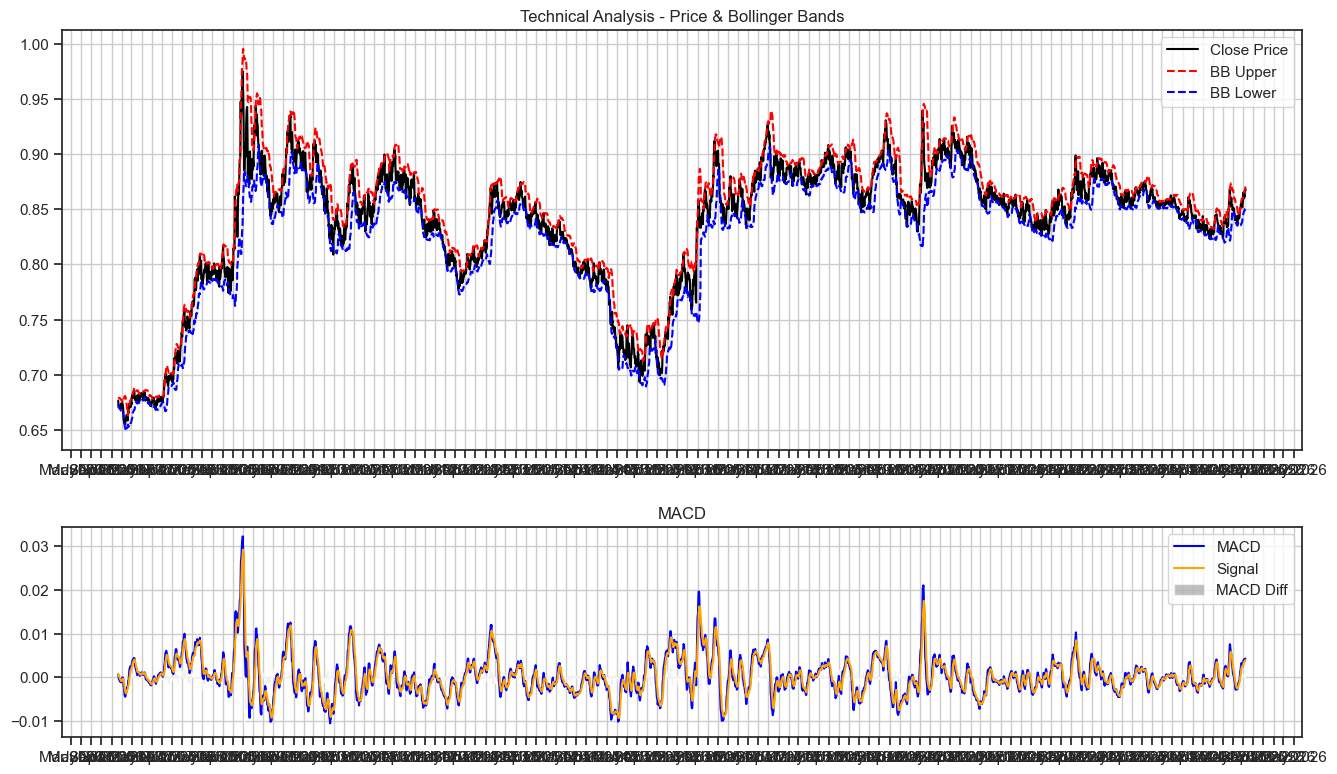

In [410]:
plot_bb_macd_chart(df)

In [411]:
# Display the list of all column names in the DataFrame
df.columns.tolist()

['Date',
 'Open',
 'High',
 'Low',
 'Close',
 'Volume',
 'Candle_Size',
 'Upper_Wick_Ratio',
 'Lower_Wick_Ratio',
 'Body_to_Range',
 'dayofweek',
 'month',
 'Log_Return',
 'RSI',
 'MACD',
 'MACD_signal',
 'MACD_diff',
 'BB_upper',
 'BB_lower',
 'BB_width',
 'SMA_10',
 'SMA_20',
 'SMA_50',
 'SMA_100',
 'ATR']

In [412]:
# Create a new DataFrame `comp` by dropping non-essential or categorical columns 
# such as 'dayofweek', 'month', and 'Volume' if they exist
comp = df.drop(columns=["dayofweek", "month", "Volume"], errors='ignore')

In [413]:
# Import seaborn for enhanced visualizations
import seaborn as sns

# Defining a function to plot a heatmap of correlations between numerical features
def plot_correlation_heatmap(comp):
    plt.figure(figsize=(10, 6))  # Set the figure size
    sns.heatmap(
        comp.corr(numeric_only=True),  # Compute correlation matrix of numeric columns
        annot=True,                    # Display correlation values in the heatmap
        cmap='coolwarm',               # Use a diverging colormap for clarity
        center=0                       # Center the colormap at 0 for balanced visual
    )
    plt.title("Correlation Heatmap of Technical Indicators")
    plt.show()

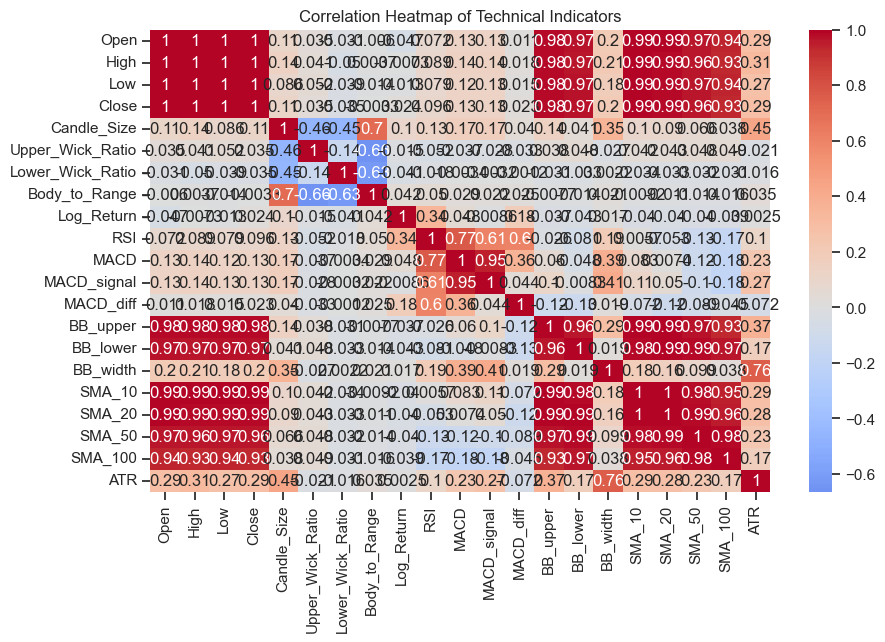

In [414]:
# Call the function to display the correlation heatmap for the technical indicators in 'comp'
plot_correlation_heatmap(comp)

In [415]:
# Define a function to visualize the price trend along with SMAs and Bollinger Bands
def plot_price_trend(df, title="Price & Trend"):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])  # Ensure 'Date' is in datetime format

    # === Plot Price and Trend Indicators ===
    plt.figure(figsize=(16, 8))
    plt.plot(df['Date'], df['Close'], label='Close Price', color='black', linewidth=1.5)        # Closing price
    plt.plot(df['Date'], df['SMA_20'], label='SMA 20', color='blue', linestyle='--')            # 20-day SMA
    plt.plot(df['Date'], df['SMA_50'], label='SMA 50', color='green', linestyle='--')           # 50-day SMA
    plt.plot(df['Date'], df['SMA_100'], label='SMA 100', color='yellow', linestyle='--')        # 100-day SMA
    plt.plot(df['Date'], df['BB_upper'], label='BB Upper', color='red', linestyle=':')          # Upper Bollinger Band
    plt.plot(df['Date'], df['BB_lower'], label='BB Lower', color='purple', linestyle=':')       # Lower Bollinger Band
    plt.fill_between(df['Date'], df['BB_upper'], df['BB_lower'], color='gray', alpha=0.1)       # Shaded BB region

    # === Customize Plot Aesthetics ===
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.grid(True)
    plt.legend()

    # Format x-axis with month-year ticks every 2 months
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

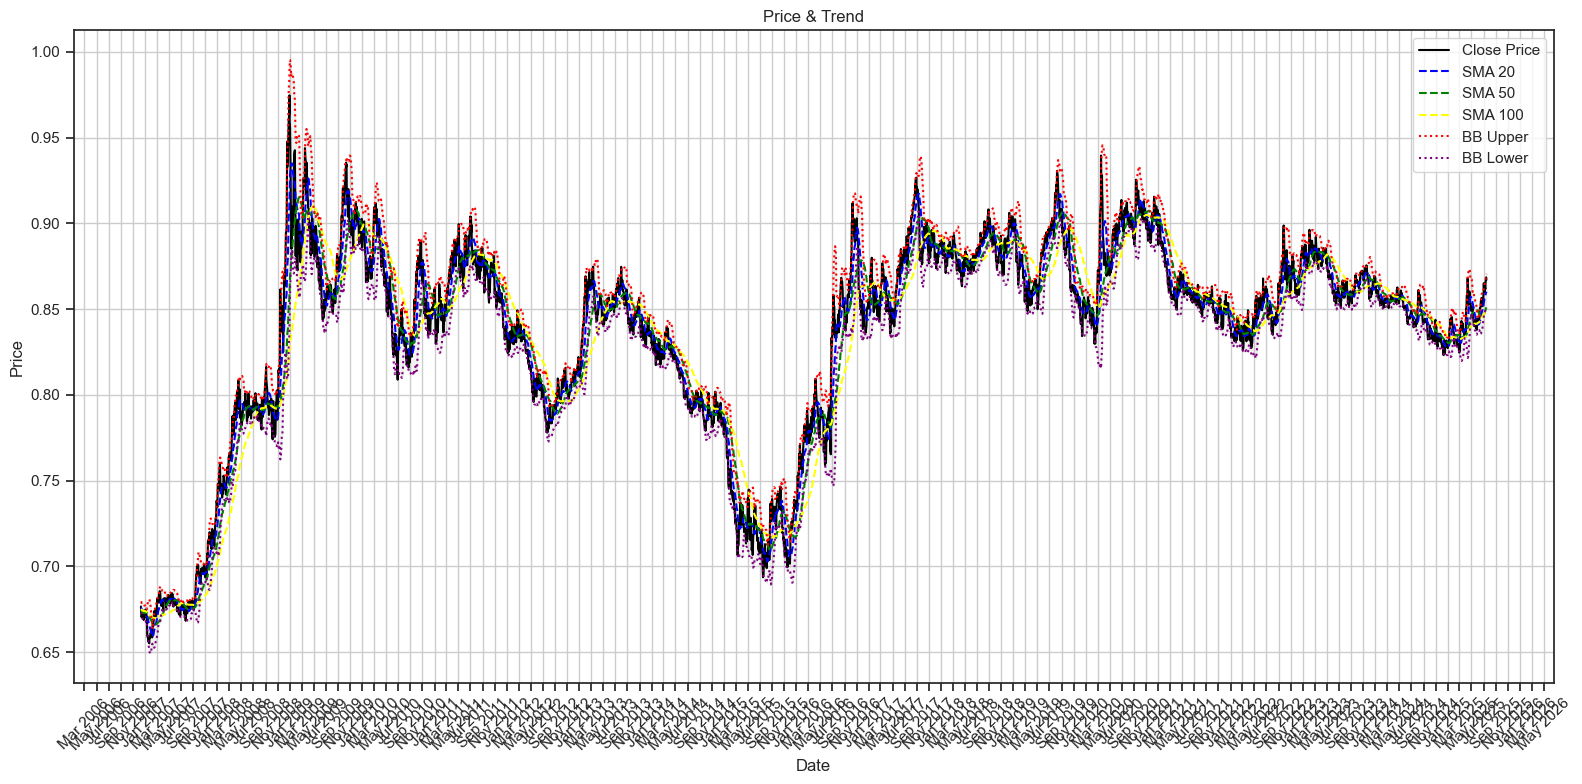

In [416]:
plot_price_trend(df)

In [417]:
# Define a function to plot a scatter matrix (pair plot) for selected technical indicators
def plot_scatter_matrix(df, indicators=None, title="Indicator Pair Plot"):
    # Set default indicators to plot if none are specified
    if indicators is None:
        indicators = ['Close', 'RSI', 'MACD', 'MACD_signal', 'BB_width']

    # Select specified columns and drop rows with missing values
    data = df[indicators].dropna()

    # Plot pairwise relationships with KDE on diagonals and scatter plots on lower triangle
    sns.set(style="ticks", color_codes=True)
    sns.pairplot(data, diag_kind="kde", corner=True)
    plt.suptitle(title, y=1.02)  # Set the main title above the plot
    plt.show()

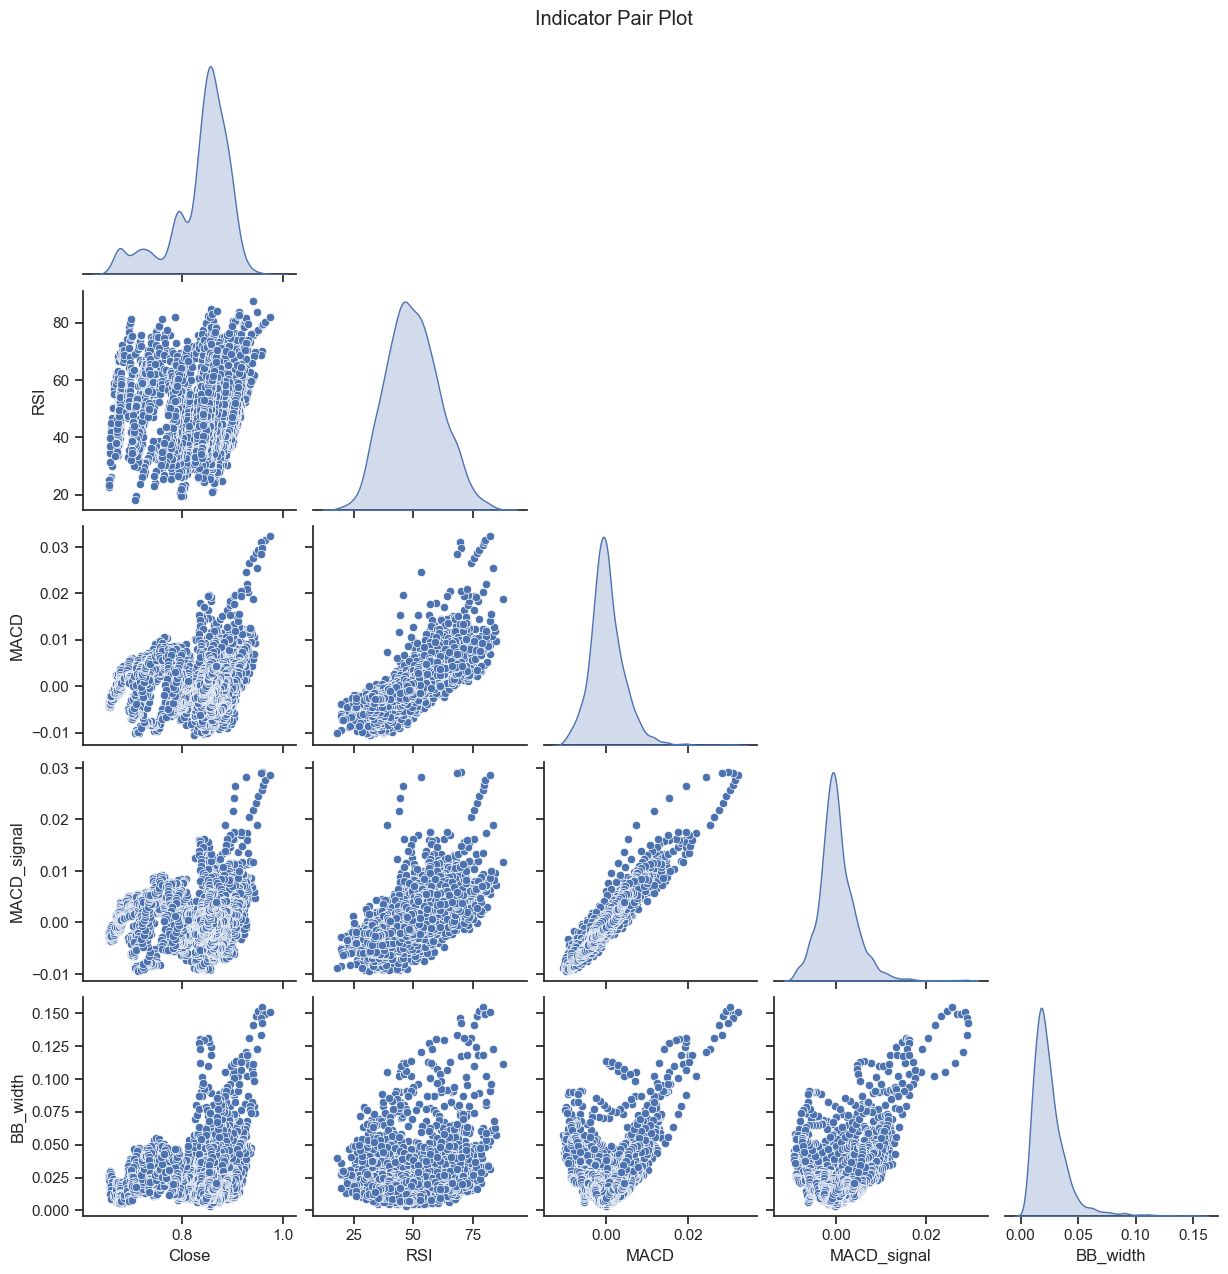

In [418]:
plot_scatter_matrix(df)

In [419]:
# FEATURE ENGINEERING

In [420]:
# === Lag Features ===
# Create lagged versions of the 'Close' price to capture historical price behavior as features
df['lag_1'] = df['Close'].shift(1)  # Close price from 1 day ago
df['lag_2'] = df['Close'].shift(2)  # Close price from 2 days ago
df['lag_3'] = df['Close'].shift(3)  # Close price from 3 days ago

In [421]:
# === Return Features ===
# Calculate the 1-day percentage return of the closing price
df['return_1d'] = ((df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1)) * 100

In [422]:
# === Rolling Statistics ===
# Compute rolling statistics to capture short- and medium-term trends and volatility

df['sma_5'] = df['Close'].rolling(5).mean()        # 5-day simple moving average
df['sma_10'] = df['Close'].rolling(10).mean()      # 10-day simple moving average
df['sma_21'] = df['Close'].rolling(21).mean()      # 21-day simple moving average (approx. 1 trading month)

df['volatility_10'] = df['Close'].rolling(10).std()  # 10-day rolling standard deviation (volatility)
df['volatility_21'] = df['Close'].rolling(21).std()  # 21-day rolling standard deviation (volatility)

In [423]:
# === Price Action Features ===

# Extract series for OHLC prices
high_series = df['High'].squeeze()
low_series = df['Low'].squeeze()
open_series = df['Open'].squeeze()
close_series = df['Close'].squeeze()

# Compute the larger value between Open and Close for each row (top of the real body)
high_body_max = pd.concat([open_series, close_series], axis=1).max(axis=1)

# Compute the smaller value between Open and Close for each row (bottom of the real body)
low_body_min = pd.concat([open_series, close_series], axis=1).min(axis=1)

# Calculate upper shadow: difference between the High and the top of the candle body
df['upper_shadow'] = high_series - high_body_max

# Calculate lower shadow: difference between the bottom of the candle body and the Low
df['lower_shadow'] = low_body_min - low_series

In [424]:
# === Temporal Features ===
# Extract time-based features from the 'Date' column

df['dayofweek'] = df['Date'].dt.dayofweek              # Day of the week (0 = Monday, ..., 6 = Sunday)
df['month'] = df['Date'].dt.month                      # Month of the year (1 = January, ..., 12 = December)

# Flags to identify start and end of the trading week
df['is_week_start'] = (df['dayofweek'] == 0).astype(int)  # 1 if Monday, else 0
df['is_week_end'] = (df['dayofweek'] == 4).astype(int)    # 1 if Friday, else 0

In [425]:
# === Targets ===
# Define target variables for supervised learning tasks

df['target_regression'] = df['Close'].shift(-1)                   # Next day's closing price (for regression)
df['target_classification'] = (df['Close'].shift(-1) > df['Close']).astype(int)  # 1 if price goes up next day, else 0 (for classification)

In [426]:
# Remove any remaining rows with missing values to ensure model compatibility
df.dropna(inplace=True)

# Reset the DataFrame index after dropping rows to maintain a clean, continuous index
df.reset_index(drop=True, inplace=True)

In [427]:
df.head()

,Date,Open,High,Low,Close,Volume,Candle_Size,Upper_Wick_Ratio,Lower_Wick_Ratio,Body_to_Range,...,sma_10,sma_21,volatility_10,volatility_21,upper_shadow,lower_shadow,is_week_start,is_week_end,target_regression,target_classification
0,2007-01-08,0.6739,0.6744,0.6713,0.6720,0,0.0019,0.161290,0.225806,0.612903,...,0.67253,0.672043,0.001781,0.001982,0.0005,0.0007,1,0,0.6701,0
1,2007-01-09,0.6720,0.6722,0.6693,0.6701,0,0.0019,0.068966,0.275862,0.655172,...,0.67251,0.671733,0.001810,0.001726,0.0002,0.0008,0,0,0.6694,0
2,2007-01-10,0.6701,0.6709,0.6686,0.6694,0,0.0007,0.347826,0.347826,0.304348,...,0.67241,0.671524,0.001961,0.001730,0.0008,0.0008,0,0,0.6627,0
3,2007-01-11,0.6692,0.6706,0.6621,0.6627,0,0.0065,0.164706,0.070588,0.764706,...,0.67169,0.671090,0.003612,0.002585,0.0014,0.0006,0,0,0.6594,0
4,2007-01-12,0.6626,0.6639,0.6588,0.6594,0,0.0032,0.254902,0.117647,0.627451,...,0.67023,0.670571,0.005183,0.003634,0.0013,0.0006,0,1,0.6585,0


In [428]:
# Calculate the absolute size of the candlestick body (difference between Close and Open)
df['body'] = (df['Close'] - df['Open']).abs()

# Display the first 5 values of the 'body' column
df['body'].head()

0    0.0019
1    0.0019
2    0.0007
3    0.0065
4    0.0032
Name: body, dtype: float64

In [429]:
df['body'].describe()

count    4880.000000
mean        0.003018
std         0.002978
min         0.000000
25%         0.000990
50%         0.002200
75%         0.004103
max         0.047100
Name: body, dtype: float64

In [430]:
# === Candle Attributes ===

# Calculate the full candlestick range (high - low) for each day
df['range'] = df['High'] - df['Low']

# Determine the top and bottom of the candlestick body
high_body_max = df[['Open', 'Close']].max(axis=1)  # Upper edge of the candle body
low_body_min = df[['Open', 'Close']].min(axis=1)   # Lower edge of the candle body

# Calculate the size of the upper shadow (wick above the body)
df['upper_shadow'] = df['High'].astype(float) - high_body_max.astype(float)

# Calculate the size of the lower shadow (wick below the body)
df['lower_shadow'] = low_body_min - df['Low']

In [431]:
# === Candlestick Flags ===
# Identify specific candlestick patterns based on body and shadow proportions

# Doji: very small body relative to total range (indecision in the market)
df['is_doji'] = (df['body'] / df['range'] < 0.1).astype(int)

# Hammer: small body with long lower shadow and tiny upper shadow (potential bullish reversal)
df['is_hammer'] = ((df['lower_shadow'] > 2 * df['body']) & 
                   (df['upper_shadow'] < 0.1 * df['body'])).astype(int)

# Inverted Hammer: small body with long upper shadow and tiny lower shadow (potential bullish reversal in downtrend)
df['is_inverted_hammer'] = ((df['upper_shadow'] > 2 * df['body']) & 
                            (df['lower_shadow'] < 0.1 * df['body'])).astype(int)

In [432]:
# === Price Momentum Indicators ===
# Measures the absolute price change over 3 and 7 days
df['momentum_3'] = df['Close'] - df['Close'].shift(3)  # Close today minus close 3 days ago
df['momentum_7'] = df['Close'] - df['Close'].shift(7)  # Close today minus close 7 days ago

# === Rate of Change (ROC) ===
# Measures the percentage change in price over 3 and 7 days
df['roc_3'] = df['Close'].pct_change(periods=3)  # % change from 3 days ago
df['roc_7'] = df['Close'].pct_change(periods=7)  # % change from 7 days ago

# === Rolling Volatility ===
# Calculates the rolling standard deviation (volatility) of the closing price
df['vol_5'] = df['Close'].rolling(window=5).std()   # 5-day rolling volatility
df['vol_10'] = df['Close'].rolling(window=10).std() # 10-day rolling volatility

# === Slope of 5-Day Simple Moving Average (SMA) ===
# Computes the difference between consecutive SMA values to approximate its slope (trend direction)
df['sma_5_slope'] = df['sma_5'].diff()

In [433]:
# === Engulfing Patterns ===
# Store previous day's open and close prices to detect bullish and bearish engulfing patterns

df['prev_close'] = df['Close'].shift(1)  # Previous day's closing price
df['prev_open'] = df['Open'].shift(1)    # Previous day's opening price

In [434]:
# Detect classic candlestick engulfing patterns for potential trend reversals

# Bullish Engulfing:
# Previous candle is bearish (close < open), current is bullish (close > open),
# and current body completely engulfs the previous body
df['is_bullish_engulfing'] = (
    (df['prev_close'] > df['prev_open']) &          # Previous candle is bearish
    (df['Close'] > df['Open']) &                    # Current candle is bullish
    (df['Open'] < df['prev_close']) &               # Current open is lower than previous close
    (df['Close'] > df['prev_open'])                 # Current close is higher than previous open
).astype(int)

# Bearish Engulfing:
# Previous candle is bullish, current is bearish, and current body engulfs previous
df['is_bearish_engulfing'] = (
    (df['prev_open'] > df['prev_close']) &          # Previous candle is bullish
    (df['Close'] < df['Open']) &                    # Current candle is bearish
    (df['Open'] > df['prev_close']) &               # Current open is higher than previous close
    (df['Close'] < df['prev_open'])                 # Current close is lower than previous open
).astype(int)

In [435]:
# === Trend Indicators ===
# Create binary features to capture trend direction and momentum

df['price_above_sma20'] = (df['Close'] > df['SMA_20']).astype(int)     # 1 if price is above 20-day SMA else 0
df['price_above_sma50'] = (df['Close'] > df['SMA_50']).astype(int)     # 1 if price is above 50-day SMA else 0
df['sma_crossover'] = (df['SMA_20'] > df['SMA_50']).astype(int)        # 1 if short-term SMA crosses above long-term SMA else 0
df['log_return_positive'] = (df['Log_Return'] > 0).astype(int)         # 1 if log return is positive (price increased) else 0

In [436]:
# Drop temporary columns used for engulfing pattern detection to clean up the DataFrame
df.drop(columns=['prev_open', 'prev_close'], inplace=True)

In [437]:
df.isnull().sum()

Date                     0
Open                     0
High                     0
Low                      0
Close                    0
Volume                   0
Candle_Size              0
Upper_Wick_Ratio         0
Lower_Wick_Ratio         0
Body_to_Range            0
dayofweek                0
month                    0
Log_Return               0
RSI                      0
MACD                     0
MACD_signal              0
MACD_diff                0
BB_upper                 0
BB_lower                 0
BB_width                 0
SMA_10                   0
SMA_20                   0
SMA_50                   0
SMA_100                  0
ATR                      0
lag_1                    0
lag_2                    0
lag_3                    0
return_1d                0
sma_5                    0
sma_10                   0
sma_21                   0
volatility_10            0
volatility_21            0
upper_shadow             0
lower_shadow             0
is_week_start            0
i

In [438]:
df.dropna(inplace=True)

In [439]:
df.columns.tolist()

['Date',
 'Open',
 'High',
 'Low',
 'Close',
 'Volume',
 'Candle_Size',
 'Upper_Wick_Ratio',
 'Lower_Wick_Ratio',
 'Body_to_Range',
 'dayofweek',
 'month',
 'Log_Return',
 'RSI',
 'MACD',
 'MACD_signal',
 'MACD_diff',
 'BB_upper',
 'BB_lower',
 'BB_width',
 'SMA_10',
 'SMA_20',
 'SMA_50',
 'SMA_100',
 'ATR',
 'lag_1',
 'lag_2',
 'lag_3',
 'return_1d',
 'sma_5',
 'sma_10',
 'sma_21',
 'volatility_10',
 'volatility_21',
 'upper_shadow',
 'lower_shadow',
 'is_week_start',
 'is_week_end',
 'target_regression',
 'target_classification',
 'body',
 'range',
 'is_doji',
 'is_hammer',
 'is_inverted_hammer',
 'momentum_3',
 'momentum_7',
 'roc_3',
 'roc_7',
 'vol_5',
 'vol_10',
 'sma_5_slope',
 'is_bullish_engulfing',
 'is_bearish_engulfing',
 'price_above_sma20',
 'price_above_sma50',
 'sma_crossover',
 'log_return_positive']

In [440]:
from datetime import timedelta

# Get today's date in UTC without timezone information, and normalize it to midnight (00:00:00)
today = pd.Timestamp.utcnow().replace(tzinfo=None).normalize()

# Calculate the date exactly two weeks ago from today
two_weeks_ago = today - timedelta(days=14)

# Ensure the 'Date' column in the DataFrame is timezone-naive (i.e., has no timezone info)
df['Date'] = pd.to_datetime(df['Date']).dt.tz_localize(None)

# Split the dataset into two parts:
# 1. Training data: all rows with dates older than two weeks ago
df_train = df[df['Date'] < two_weeks_ago].reset_index(drop=True)

# 2. Most recent two weeks: data from two weeks ago up to today
df_last_2weeks = df[df['Date'] >= two_weeks_ago].reset_index(drop=True)

In [441]:
df_last_2weeks.shape

(12, 58)

In [442]:
# MODEL TRAINING

In [443]:
# Import train_test_split to divide the dataset into training and testing sets
from sklearn.model_selection import TimeSeriesSplit
from features import FeatureEngineer

In [444]:
tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(df_org):
    pass 

df_train = df_org.iloc[train_index]
df_test = df_org.iloc[test_index]

In [445]:
fe = FeatureEngineer()
df_train_fe = fe.transform(df_train)
df_test_fe = fe.transform(df_test)

In [446]:
df_train_fe.shape, df_test_fe.shape

((4068, 58), (734, 58))

In [447]:
df_train_fe.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Candle_Size',
       'Upper_Wick_Ratio', 'Lower_Wick_Ratio', 'Body_to_Range', 'dayofweek',
       'month', 'is_week_start', 'is_week_end', 'Log_Return', 'RSI', 'MACD',
       'MACD_signal', 'MACD_diff', 'BB_upper', 'BB_lower', 'BB_width',
       'SMA_10', 'SMA_20', 'SMA_50', 'SMA_100', 'ATR', 'lag_1', 'lag_2',
       'lag_3', 'return_1d', 'sma_5', 'sma_10', 'sma_21', 'volatility_10',
       'volatility_21', 'upper_shadow', 'lower_shadow', 'target_regression',
       'target_classification', 'body', 'range', 'is_doji', 'is_hammer',
       'is_inverted_hammer', 'momentum_3', 'momentum_7', 'roc_3', 'roc_7',
       'vol_5', 'vol_10', 'sma_5_slope', 'is_bullish_engulfing',
       'is_bearish_engulfing', 'price_above_sma20', 'price_above_sma50',
       'sma_crossover', 'log_return_positive'],
      dtype='object')

In [448]:
assert len(df.columns) == len(df_train_fe.columns)

In [449]:
# Define the target variable for regression and select input features
target = 'target_regression'

In [450]:
# Drop target columns and non-feature columns for X,  # Feature matrix
X_train = df_train_fe.drop(columns=['Date', 'target_regression', 'target_classification'], errors='ignore')
X_test = df_test_fe.drop(columns=['Date', 'target_regression', 'target_classification'], errors='ignore')

In [451]:
# Target variable (next day's closing price)
y_train = df_train_fe[target]
y_test = df_test_fe[target]

In [452]:
X_train.columns.tolist()

['Open',
 'High',
 'Low',
 'Close',
 'Volume',
 'Candle_Size',
 'Upper_Wick_Ratio',
 'Lower_Wick_Ratio',
 'Body_to_Range',
 'dayofweek',
 'month',
 'is_week_start',
 'is_week_end',
 'Log_Return',
 'RSI',
 'MACD',
 'MACD_signal',
 'MACD_diff',
 'BB_upper',
 'BB_lower',
 'BB_width',
 'SMA_10',
 'SMA_20',
 'SMA_50',
 'SMA_100',
 'ATR',
 'lag_1',
 'lag_2',
 'lag_3',
 'return_1d',
 'sma_5',
 'sma_10',
 'sma_21',
 'volatility_10',
 'volatility_21',
 'upper_shadow',
 'lower_shadow',
 'body',
 'range',
 'is_doji',
 'is_hammer',
 'is_inverted_hammer',
 'momentum_3',
 'momentum_7',
 'roc_3',
 'roc_7',
 'vol_5',
 'vol_10',
 'sma_5_slope',
 'is_bullish_engulfing',
 'is_bearish_engulfing',
 'price_above_sma20',
 'price_above_sma50',
 'sma_crossover',
 'log_return_positive']

In [453]:
# Display the shape of the training feature set (rows, columns)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4068, 55), (734, 55), (4068,), (734,))

In [454]:
# Import the Prophet library for time series forecasting
from prophet import Prophet

In [455]:
# Import Augmented Dickey-Fuller test from statsmodels to check for stationarity
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test on the 'Close' price series
adf_test = adfuller(df_train['Close'])

# Organize and display the ADF test results
adf_results = {
    "Test Statistic": adf_test[0],                   # The test statistic value
    "p-value": adf_test[1],                          # p-value to assess stationarity
    "Lags Used": adf_test[2],                        # Number of lags used in the test
    "Number of Observations Used": adf_test[3],      # Number of observations included
    "Critical Values": adf_test[4],                  # Critical values at 1%, 5%, and 10% confidence levels
}

# Print results in a readable format
for key, value in adf_results.items():
    print(f"{key}: {value}")

Test Statistic: -2.693862468039224
p-value: 0.07510636511949342
Lags Used: 2
Number of Observations Used: 4164
Critical Values: {'1%': -3.431921406292311, '5%': -2.8622343609798317, '10%': -2.5671396144552685}


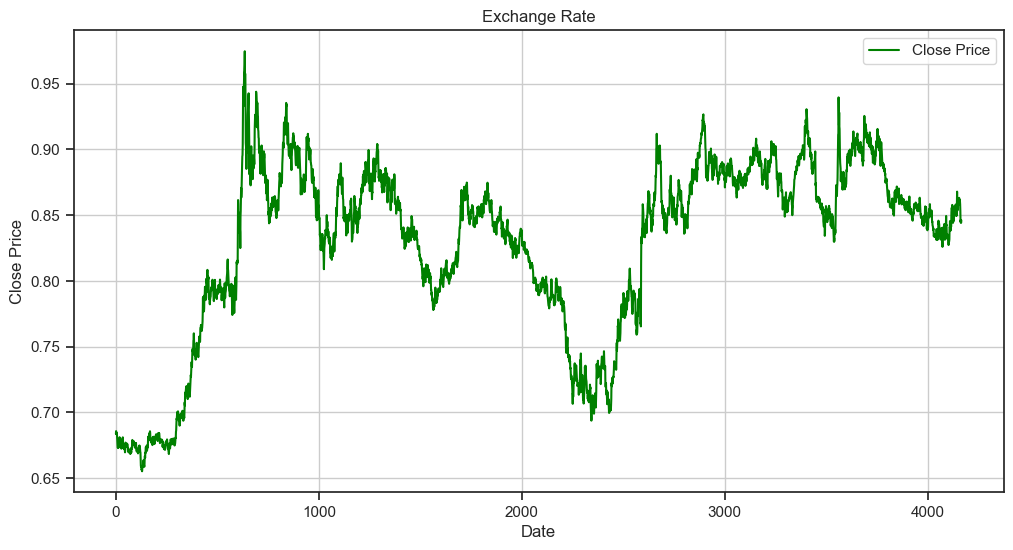

In [456]:
# Plot the differenced 'Close' price to visualize stationarity

plt.figure(figsize=(12, 6))
plt.plot(df_train.index, df_train['Close'], label='Close Price', color='green')  # Plot differenced close prices
plt.title("Exchange Rate")                                       # Chart title
plt.xlabel("Date")                                                       # X-axis label
plt.ylabel("Close Price")                                                # Y-axis label
plt.legend()
plt.grid()
plt.show()

In [457]:
# === Model Evaluation Metrics ===

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define a function to evaluate and print regression performance metrics
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)             # Mean Absolute Error
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))    # Root Mean Squared Error
    r2 = r2_score(y_true, y_pred)                          # R-squared score

    # Display evaluation results
    print(f"{name} Evaluation:")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")
    print()

In [458]:
usable_regressors = [
    'MACD_signal',
    'Log_Return',
    'BB_width'

]

In [459]:
"""usable_regressors = [
    'Log_Return', 'RSI', 'MACD', 'MACD_signal', 'MACD_diff',
    'BB_width', 'SMA_10', 'SMA_20', 'SMA_50', 'SMA_100',
    'ATR', 'return_1d', 'sma_5', 'sma_10', 'sma_21',
    'volatility_10', 'volatility_21', 'upper_shadow',
    'lower_shadow', 'body', 'range'
]"""

"usable_regressors = [\n    'Log_Return', 'RSI', 'MACD', 'MACD_signal', 'MACD_diff',\n    'BB_width', 'SMA_10', 'SMA_20', 'SMA_50', 'SMA_100',\n    'ATR', 'return_1d', 'sma_5', 'sma_10', 'sma_21',\n    'volatility_10', 'volatility_21', 'upper_shadow',\n    'lower_shadow', 'body', 'range'\n]"

In [460]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_train_fe[usable_regressors] = scaler.fit_transform(df_train_fe[usable_regressors])
df_test_fe[usable_regressors] = scaler.transform(df_test_fe[usable_regressors])


In [461]:
# Initialize and fit the Prophet model for forecasting

# Prepare the DataFrame in Prophet's expected format:
# 'ds' for datetime column and 'y' for the target variable
# Prepare input for Prophet
# Prepare input DataFrame for Prophet
prophet_df = df_train_fe[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})

# Add all available usable regressors
for reg in usable_regressors:
    if reg in df_train_fe.columns:
        prophet_df[reg] = df_train_fe[reg]

# Initialize the Prophet model with daily seasonality enabled
prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    interval_width=0.80,  # This sets 80% prediction interval
    changepoint_prior_scale=0.002,      # Higher = more flexible trend shifts
    seasonality_prior_scale=10.0      # Higher = more seasonal variation
)

prophet.add_seasonality(name='quarterly', period=91.25, fourier_order=5)

# Register the regressors with the model
for reg in usable_regressors:
    if reg in prophet_df.columns:
        prophet.add_regressor(reg)
    
# Fit the Prophet model to the data
prophet.fit(prophet_df)

16:18:21 - cmdstanpy - INFO - Chain [1] start processing
16:18:24 - cmdstanpy - INFO - Chain [1] done processing


In [462]:
# === Make Forecast with Prophet using All Usable Regressors ===

# Create a future dataframe that extends the timeline by the length of the test set
future = prophet.make_future_dataframe(periods=len(df_test_fe), freq='D')

# Pad future regressors
for reg in usable_regressors:
    if reg in df_train_fe.columns and reg in df_test_fe.columns:
        recent_val = df_train_fe[reg].dropna().values[-1]
        reg_full = np.concatenate([
            df_train_fe[reg].dropna().values[-(len(future) - len(df_test_fe)):],
            [recent_val] * len(df_test_fe)
        ])
        future[reg] = reg_full[-len(future):]

# Generate forecast for both historical and future dates
forecast = prophet.predict(future)

# Extract predicted values for test period
prophet_preds = forecast[['yhat', 'yhat_lower', 'yhat_upper']].iloc[-len(df_test_fe):]
prophet_preds.shape

(734, 3)

In [463]:
actual = df_test_fe['Close'].values 
dates = df_test_fe['Date'].values 

In [464]:
evaluate_model("Prophet", actual, prophet_preds['yhat'])

Prophet Evaluation:
MAE:  0.0108
RMSE: 0.0134
R²:   0.2903



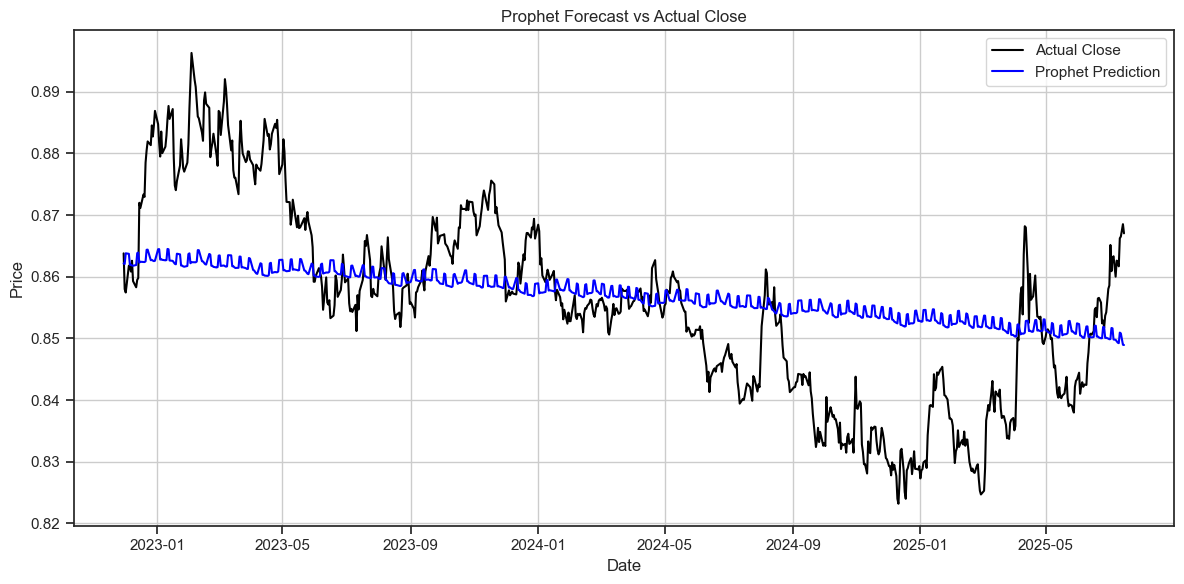

In [465]:
# === Plot Prophet Forecast vs Actual Close Prices ===

plt.figure(figsize=(12, 6))

# Plot actual close prices
plt.plot(dates, actual, label='Actual Close', color='black')

# Plot predicted close prices from Prophet
plt.plot(dates, prophet_preds['yhat'], label='Prophet Prediction', color='blue')

plt.title('Prophet Forecast vs Actual Close')  # Chart title
plt.xlabel('Date')                             # X-axis label
plt.ylabel('Price')                            # Y-axis label
plt.legend()                                   # Display legend
plt.grid(True)                                 # Add grid for readability
plt.tight_layout()                             # Optimize layout
plt.show()                                     # Render the plot

In [466]:
prophet_preds['yhat_lower']

4068    0.823480
4069    0.828513
4070    0.830070
4071    0.826641
4072    0.822358
          ...   
4797    0.805800
4798    0.803631
4799    0.807277
4800    0.802039
4801    0.804106
Name: yhat_lower, Length: 734, dtype: float64

In [467]:
# ARIMA

In [468]:
# === ARIMA Forecasting ===
from pmdarima import auto_arima

# === Prepare target and exogenous ===
y_arima_train = df_train_fe['Close'].iloc[:-len(X_test)]
X_arima_train = X_train
X_arima_test = X_test
test_dates = df_train_fe['Date'].iloc[-len(X_arima_test):].values

In [469]:
arima_model = auto_arima(
    y=y_arima_train,
    exogenous=X_arima_train,
    start_p=1, start_q=1,
    max_p=5, max_q=5,
    seasonal=False,
    d=0,  # no differencing, predict actual values
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore'
)

In [470]:
# Forecast Close using test exogenous features
arima_preds = arima_model.predict(n_periods=len(X_arima_test), exogenous=X_arima_test)
actual_close = df_train_fe['Close'].iloc[-len(X_arima_test):].values

# Create a DataFrame to compare ARIMA predictions with actual close prices for the test period
arima_plot_df = pd.DataFrame({
    'Date': test_dates, # Corresponding dates
    'Actual_Close': actual_close, # Actual close prices
    'ARIMA_Predicted': arima_preds # Predicted close prices from ARIMA
})

In [471]:
evaluate_model("ARIMA (Auto)", actual_close, arima_preds)

ARIMA (Auto) Evaluation:
MAE:  0.0243
RMSE: 0.0294
R²:   -0.4282



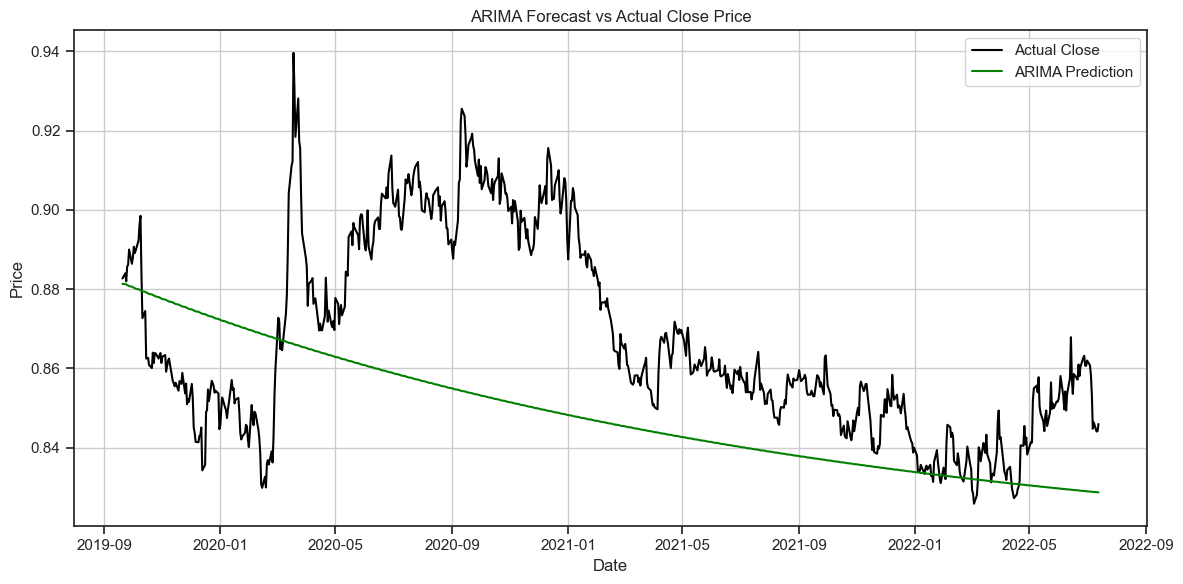

In [472]:
# === Plot ARIMA Forecast vs Actual Close Prices ===

plt.figure(figsize=(12, 6))

# Plot actual close prices
plt.plot(arima_plot_df['Date'], arima_plot_df['Actual_Close'], label='Actual Close', color='black')

# Plot ARIMA predicted close prices
plt.plot(arima_plot_df['Date'], arima_plot_df['ARIMA_Predicted'], label='ARIMA Prediction', color='green')

plt.title('ARIMA Forecast vs Actual Close Price')  # Title of the plot
plt.xlabel('Date')                                 # Label for the x-axis
plt.ylabel('Price')                                # Label for the y-axis
plt.legend()                                       # Show legend to distinguish lines
plt.grid(True)                                     # Add gridlines for better readability
plt.tight_layout()                                 # Adjust layout to fit elements neatly
plt.show()                                         # Display the plot

In [473]:
# LSTM

In [474]:
# === Preprocessing ===
from sklearn.preprocessing import MinMaxScaler  # Scales features to a 0–1 range, improving neural network convergence

# === Keras Model Components ===
from tensorflow.keras.models import Sequential  # Used to build a linear stack of layers for the model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional  
# LSTM: Long Short-Term Memory layer for capturing temporal dependencies
# Dense: Fully connected layer for output or hidden layers
# Dropout: Regularization layer to prevent overfitting by randomly deactivating neurons during training
# Bidirectional: Wraps LSTM to process input in both forward and backward directions

# === Optimizer ===
from tensorflow.keras.optimizers import Adam  # Adaptive optimizer used for updating network weights efficiently

# === Callback ===
from tensorflow.keras.callbacks import EarlyStopping  
# Stops training early if the validation performance stops improving, to avoid overfitting

In [475]:
def reshape_for_lstm(X, y, timesteps=10):
    """
    Transforms feature matrix X and target y into a 3D shape suitable for LSTM input.
    
    Parameters:
        X (array-like): Feature data of shape (samples, features)
        y (array-like): Target values aligned with X
        timesteps (int): Number of past time steps to include for each input sample
    
    Returns:
        X_lstm (np.array): 3D array shaped (samples - timesteps, timesteps, features)
        y_lstm (np.array): Target values corresponding to each X_lstm window
    """
    X_lstm, y_lstm = [], []
    y = np.array(y)  # Ensure y is a NumPy array
    
    # Loop over the data starting from the 'timesteps'-th row
    for i in range(timesteps, len(X)):
        # Take the window of `timesteps` rows as one LSTM input
        X_lstm.append(X[i - timesteps:i])
        # The label is the value right after the window
        y_lstm.append(y[i])
    
    return np.array(X_lstm), np.array(y_lstm)

In [476]:
# === Feature Normalization ===
scaler = MinMaxScaler()  
# Initialize MinMaxScaler to scale features to the [0, 1] range — this helps neural networks converge faster

X_train_scaled = scaler.fit_transform(X_train)  
# Fit the scaler on the training data and transform it — important to avoid data leakage

X_test_scaled = scaler.transform(X_test)  
# Apply the same transformation to the test data using the scaler fitted on training data

In [477]:
# === Reshape Scaled Data for LSTM ===
# Converts the 2D feature arrays into 3D format expected by LSTM:
# (samples, timesteps, features)

X_lstm_train, y_lstm_train = reshape_for_lstm(X_train_scaled, y_train, timesteps=10)
# Generates LSTM-compatible training inputs and targets using a rolling window of 10 timesteps

X_lstm_test, y_lstm_test = reshape_for_lstm(X_test_scaled, y_test, timesteps=10)
# Generates LSTM-compatible testing inputs and targets using the same window size

In [478]:
# === LSTM Model Architecture ===
model = Sequential()  
# Create a sequential model — layers will be added one by one in order

# Add a Bidirectional LSTM layer with 64 units
# Processes the sequence forward and backward to capture richer temporal patterns
# return_sequences=False means it only returns the final output (not the full sequence)
model.add(Bidirectional(
    LSTM(units=64, return_sequences=False),
    input_shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])  # (timesteps, features)
))

model.add(Dropout(0.3))                      # Dropout after LSTM

# Add a fully connected dense layer with 32 neurons and ReLU activation
# Helps in learning non-linear combinations of LSTM outputs
model.add(Dense(32, activation='relu'))

# Add dropout for regularization — randomly sets 30% of input units to zero during training
model.add(Dropout(0.3))

# Output layer with 1 neuron (for regression output, i.e., next predicted price)
model.add(Dense(1))

In [479]:
# === Compile the LSTM Model ===
model.compile(
    optimizer=Adam(learning_rate=0.001),  # Use Adam optimizer with a learning rate of 0.01
    loss='mse',  # Use Mean Squared Error loss — suitable for regression tasks
    metrics=['mae']   
)

split_idx = int(len(X_lstm_train) * 0.9)

X_train_sub = X_lstm_train[:split_idx]
X_val = X_lstm_train[split_idx:]

y_train_sub = y_lstm_train[:split_idx]
y_val = y_lstm_train[split_idx:]

model.fit(
    X_train_sub, y_train_sub,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=64,
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)]
)

# === Make Predictions on Test Data ===
# Predict the target values and flatten the output to a 1D array for easier use

Epoch 1/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 0.1683 - mae: 0.3169 - val_loss: 0.0108 - val_mae: 0.1017
Epoch 2/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0475 - mae: 0.1731 - val_loss: 0.0052 - val_mae: 0.0700
Epoch 3/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0384 - mae: 0.1567 - val_loss: 0.0024 - val_mae: 0.0465
Epoch 4/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0286 - mae: 0.1362 - val_loss: 6.7462e-04 - val_mae: 0.0233
Epoch 5/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0239 - mae: 0.1239 - val_loss: 0.0011 - val_mae: 0.0308
Epoch 6/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0236 - mae: 0.1226 - val_loss: 0.0026 - val_mae: 0.0501
Epoch 7/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0200 - mae: 0.1122 - val_loss: 0.0019 - val_mae: 0.0413
Epoch 8/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0185 - mae: 0.1084 - val_loss: 0.0016 - val_mae: 0.0389
Epoch 9/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 

In [480]:
def predict_with_uncertainty(f_model, X_input, n_iter=100):
    preds = np.array([
        f_model(X_input, training=True).numpy().flatten()
        for _ in range(n_iter)
    ])
    mean = preds.mean(axis=0)
    lower = np.percentile(preds, 10, axis=0)
    upper = np.percentile(preds, 90, axis=0)
    return mean, lower, upper


In [481]:
lstm_preds, lstm_lower, lstm_upper = predict_with_uncertainty(model, X_lstm_test)

In [482]:
lstm_upper[0]

0.9526535272598267

In [483]:
evaluate_model("LSTM", y_lstm_test, lstm_preds)

LSTM Evaluation:
MAE:  0.0111
RMSE: 0.0136
R²:   0.2812



In [484]:
# === Prepare DataFrame for Visualization ===
lstm_plot_df = pd.DataFrame({
    'Date': df_train_fe['Date'].iloc[-len(y_lstm_test):].values,  
    # Extract the corresponding dates for the test set — same length as y_lstm_test
    # Taken from the end of the training set to match reshaped test sequences

    'Actual_Close': y_lstm_test,     # True target values from the test set
    'LSTM_Predicted': lstm_preds     # Predicted values from the trained LSTM model
})

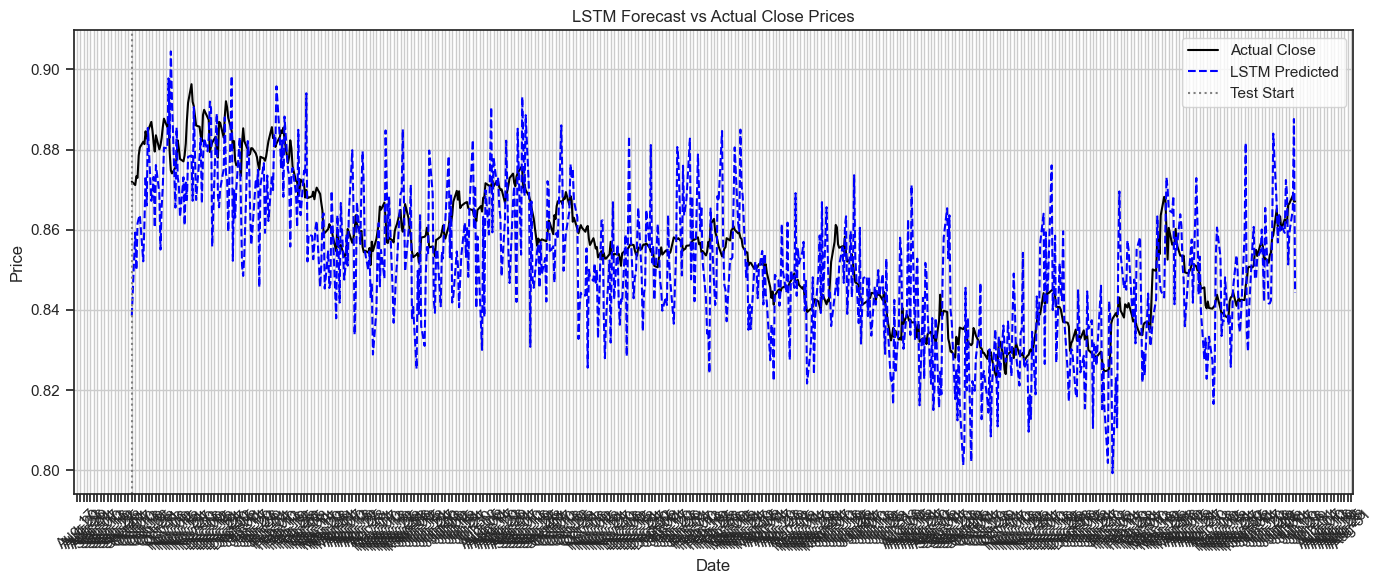

In [485]:
# Plot actual vs. predicted
plt.figure(figsize=(14, 6))
plt.plot(lstm_plot_df['Date'], lstm_plot_df['Actual_Close'], label='Actual Close', color='black')
plt.plot(lstm_plot_df['Date'], lstm_plot_df['LSTM_Predicted'], label='LSTM Predicted', color='blue', linestyle='--')

plt.axvline(x=lstm_plot_df['Date'].iloc[0], color='gray', linestyle=':', label='Test Start')

# Format x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)

plt.title("LSTM Forecast vs Actual Close Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [486]:
# XGBOOST

In [487]:
from xgboost import XGBRegressor

In [488]:
def get_quantile_model(alpha):
    return XGBRegressor(
        objective='reg:quantileerror',
        tree_method='hist',
        n_estimators=150,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        **{'quantile_alpha': alpha}  # ✅ Proper way to pass quantile alpha
    )


In [489]:
# Median prediction (main point forecast)
xgb_q50 = get_quantile_model(alpha=0.5)
xgb_q50.fit(X_train, y_train)

# Lower bound (10% confidence)
xgb_q10 = get_quantile_model(alpha=0.1)
xgb_q10.fit(X_train, y_train)

# Upper bound (90% confidence)
xgb_q90 = get_quantile_model(alpha=0.9)
xgb_q90.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=150,
             n_jobs=None, num_parallel_tree=None, ...)

In [490]:
pred_q50 = xgb_q50.predict(X_test)
pred_q10 = xgb_q10.predict(X_test)
pred_q90 = xgb_q90.predict(X_test)

In [491]:
pred_q10[0]

0.8588954

In [492]:
forecast_df = pd.DataFrame({
    "Date": test_dates,
    "Predicted_Close": pred_q50,
    "Lower_Band": pred_q10,
    "Upper_Band": pred_q90
})

In [493]:
import joblib

joblib.dump(xgb_q50, 'models/xgb_q50.pkl')
joblib.dump(xgb_q10, 'models/xgb_q10.pkl')
joblib.dump(xgb_q90, 'models/xgb_q90.pkl')


['models/xgb_q90.pkl']

In [494]:
# === Combine Actual and Model Predictions into a Single DataFrame ===
compare_df = pd.DataFrame({
    'Date': df_train['Date'].iloc[-len(y_lstm_test):].values,
    # Extracts dates aligned with LSTM test window (since reshaping skips initial rows)

    'Actual_Close': y_lstm_test,  
    # True target values from the test set

    'LSTM_Predicted': lstm_preds,  
    # Predicted values from the LSTM model

    'XGBoost_Predicted': pred_q50[-len(y_lstm_test):]  
    # Selects the last n values from XGBoost predictions to match the LSTM prediction window
})

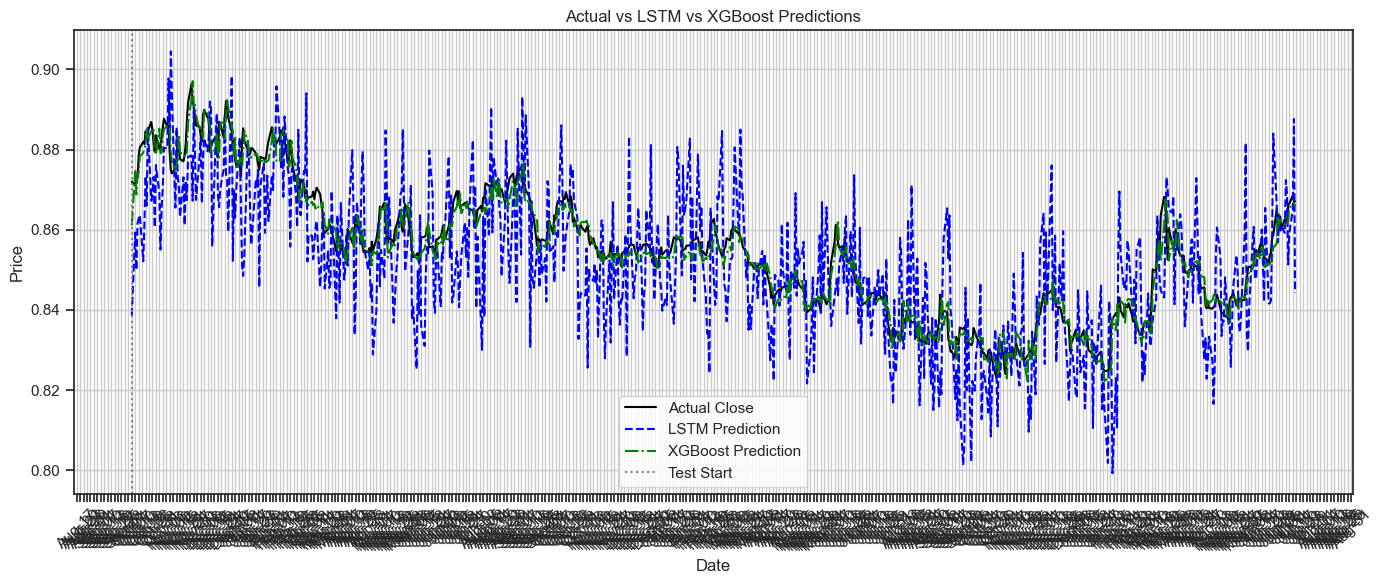

In [495]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(compare_df['Date'], compare_df['Actual_Close'], label='Actual Close', color='black')
plt.plot(compare_df['Date'], compare_df['LSTM_Predicted'], label='LSTM Prediction', color='blue', linestyle='--')
plt.plot(compare_df['Date'], compare_df['XGBoost_Predicted'], label='XGBoost Prediction', color='green', linestyle='-.')

plt.axvline(x=compare_df['Date'].iloc[0], color='gray', linestyle=':', label='Test Start')

# X-axis formatting
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)

plt.title("Actual vs LSTM vs XGBoost Predictions")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [496]:
# Ensure all prediction arrays from Prophet, ARIMA, and XGBoost have the same length for proper comparison
assert len(prophet_preds) == len(pred_q50)

In [497]:
# Ensemble models

In [498]:
len(pred_q50)

734

In [499]:
# === Average Ensemble Prediction ===
# Combine forecasts from Prophet, LSTM, and XGBoost using simple averaging

# Determine how many predictions to include — use LSTM length (shortest due to windowing)
forecast_len = len(lstm_preds)

# Trim Prophet and XGBoost predictions to match LSTM's forecast range
trimmed_prophet = prophet_preds['yhat'][-forecast_len:]     # Keep last `forecast_len` Prophet predictions
trimmed_xgb = pred_q50[-forecast_len:]             # Keep last `forecast_len` XGBoost predictions

# Compute the average of the three model outputs for each time point
ensemble_preds = (trimmed_prophet + lstm_preds + trimmed_xgb) / 3
# This produces a balanced ensemble forecast that blends strengths of all three models

In [500]:
# === Weighted Ensemble Prediction ===

# Step 1: Determine the shortest prediction length to align all model outputs
min_len = min(len(prophet_preds), len(lstm_preds), len(pred_q50))

# Step 2: Trim all predictions and ground truth to the same length from the end
prophet_trimmed = prophet_preds['yhat'][-min_len:]   # Latest Prophet predictions
lstm_trimmed = lstm_preds[-min_len:]         # Latest LSTM predictions
xgb_trimmed = pred_q50[-min_len:]           # Latest XGBoost predictions
y_test_trimmed = y_test[-min_len:]           # Corresponding true target values

# Step 3: Compute a weighted average of model predictions
# Assign heavier weight (80%) to XGBoost, and lighter weight (10% each) to Prophet and LSTM
weighted_preds = (
    0.1 * prophet_trimmed +
    0.1 * lstm_trimmed +
    0.8 * xgb_trimmed
)

# Step 4: Evaluate the weighted ensemble against the actual target values
evaluate_model("Weighted Ensemble", y_test_trimmed, weighted_preds)
# This function (assumed defined earlier) prints performance metrics like RMSE, MAE, etc.

Weighted Ensemble Evaluation:
MAE:  0.0027
RMSE: 0.0035
R²:   0.9526



In [501]:
# === Create Ensemble Comparison DataFrame ===

# Construct a DataFrame to compare actual close prices with all model predictions
# Align everything to min_len
ensemble_df = pd.DataFrame({
    'Date': df_train['Date'].iloc[-min_len:].values,
    'Actual_Close': df_train['Close'].iloc[-min_len:].values,
    'Prophet': prophet_preds['yhat'][-min_len:],
    'LSTM': lstm_preds[-min_len:],
    'XGBoost': pred_q50[-min_len:],
    'Ensemble': ensemble_preds[-min_len:],
    'Weighted Ensemble': weighted_preds[-min_len:]
})


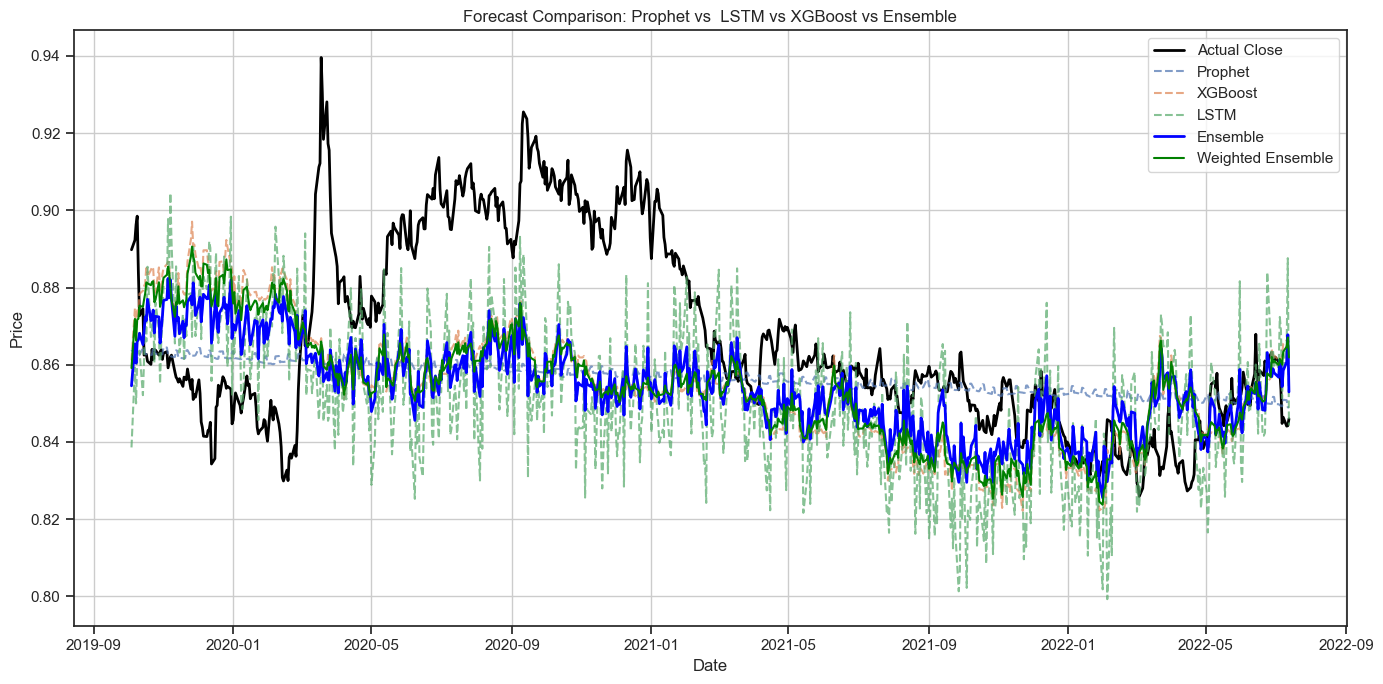

In [502]:
# === Plot Forecast Comparison ===

plt.figure(figsize=(14, 7))

# Plot actual close prices
plt.plot(ensemble_df['Date'], ensemble_df['Actual_Close'], label='Actual Close', color='black', linewidth=2)

# Plot individual model predictions
plt.plot(ensemble_df['Date'], ensemble_df['Prophet'], label='Prophet', linestyle='--', alpha=0.7)
#plt.plot(ensemble_df['Date'], ensemble_df['ARIMA'], label='ARIMA', linestyle='--', alpha=0.7)
plt.plot(ensemble_df['Date'], ensemble_df['XGBoost'], label='XGBoost', linestyle='--', alpha=0.7)
plt.plot(ensemble_df['Date'], ensemble_df['LSTM'], label='LSTM', linestyle='--', alpha=0.7)

# Plot ensemble predictions
plt.plot(ensemble_df['Date'], ensemble_df['Ensemble'], label='Ensemble', color='blue', linewidth=2)
plt.plot(ensemble_df['Date'], ensemble_df['Weighted Ensemble'], label='Weighted Ensemble', linestyle='-', color='green')

# Final plot formatting
plt.title('Forecast Comparison: Prophet vs  LSTM vs XGBoost vs Ensemble')  # Title
plt.xlabel('Date')     # X-axis label
plt.ylabel('Price')    # Y-axis label
plt.legend()           # Legend to identify lines
plt.grid(True)         # Add gridlines
plt.tight_layout()     # Adjust layout for clarity
plt.show()             # Display the plot

In [503]:
# Metrics evaluation

In [504]:
# Import regression evaluation metrics from scikit-learn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [505]:
# === Evaluate All Models ===

# Now safely evaluate models
evaluate_model("Prophet", y_test_trimmed, prophet_preds['yhat'][-min_len:])
evaluate_model("ARIMA", y_test_trimmed, arima_preds[-min_len:])
evaluate_model("XGBoost", y_test_trimmed, pred_q50[-min_len:])
evaluate_model("LSTM", y_test_trimmed, lstm_preds[-min_len:])
evaluate_model("Ensemble", y_test_trimmed, ensemble_preds[-min_len:])
evaluate_model("Weighted Ensemble", y_test_trimmed, weighted_preds[-min_len:])


Prophet Evaluation:
MAE:  0.0109
RMSE: 0.0135
R²:   0.2881

ARIMA Evaluation:
MAE:  0.0087
RMSE: 0.0112
R²:   0.5126

XGBoost Evaluation:
MAE:  0.0023
RMSE: 0.0029
R²:   0.9670

LSTM Evaluation:
MAE:  0.0111
RMSE: 0.0136
R²:   0.2812

Ensemble Evaluation:
MAE:  0.0058
RMSE: 0.0072
R²:   0.7966

Weighted Ensemble Evaluation:
MAE:  0.0027
RMSE: 0.0035
R²:   0.9526



In [506]:
# Stacking Ensembling

In [507]:
X_base = X_test[-min_len:]
X_base.shape

(724, 55)

In [508]:
# === Prepare Data for Stacking (Level 0) ===

# Trim all to match min_len
# Stack level-0 model predictions
level0_preds_10 = np.vstack([
    prophet_preds['yhat_lower'][-min_len:],
    pred_q10[-min_len:],      # XGBoost
    lstm_lower[-min_len:],    # LSTM
]).T  # Shape: (n_samples, 3)

  # Transpose to (n_samples, n_models)
stack_X_train_q10 = np.hstack([level0_preds_10, X_base])  # Shape: (n_samples, 3 + n_features)


# Align the target values
stack_y_train = y_test_trimmed.values

In [509]:
# === Prepare Data for Stacking (Level 0) ===

# Stack level-0 model predictions
level0_preds = np.vstack([
    prophet_preds['yhat'][-min_len:],
    pred_q50[-min_len:],      # XGBoost
    lstm_preds[-min_len:],    # LSTM
]).T  # Shape: (n_samples, 3)

  # Transpose to (n_samples, n_models)
stack_X_train = np.hstack([level0_preds, X_base])  # Shape: (n_samples, 3 + n_features)

In [510]:
assert len(level0_preds) == len(X_base)

In [511]:
# === Prepare Data for Stacking (Level 0) ===

# Stack level-0 model predictions
level0_preds_90 = np.vstack([
    prophet_preds['yhat_upper'][-min_len:],
    pred_q90[-min_len:],      # XGBoost
    lstm_upper[-min_len:],    # LSTM
]).T  # Shape: (n_samples, 3)

stack_X_train_q90 = np.hstack([level0_preds_90, X_base])  # Shape: (n_samples, 3 + n_features)

In [512]:
# Extract only the last train/val split
for train_index, val_index in tscv.split(stack_X_train):
    pass  # iterate to the last split

X_meta_train, X_meta_val = stack_X_train[train_index], stack_X_train[val_index]
y_meta_train, y_meta_val = stack_y_train[train_index], stack_y_train[val_index]

y_meta_val.shape

(120,)

In [513]:
# Initialize dictionary to store evaluation metrics
meta_model_scores = {}

In [514]:
# === LassoCV Meta-Model ===
from sklearn.linear_model import LassoCV

# Initialize and train Lasso with cross-validated alpha
lasso_meta = LassoCV(alphas=np.logspace(-4, 1, 50), cv=5)
lasso_meta.fit(X_meta_train, y_meta_train)

# Generate predictions
lasso_preds = lasso_meta.predict(X_meta_val)
trimmed_y_test = y_meta_val

# Evaluate and display performance
evaluate_model("LassoCV Meta", trimmed_y_test, lasso_preds)

# Store metrics in dictionary
meta_model_scores['LassoCV'] = {
    'RMSE': np.sqrt(mean_squared_error(trimmed_y_test, lasso_preds)),
    'MAE': mean_absolute_error(trimmed_y_test, lasso_preds),
    'R2': r2_score(trimmed_y_test, lasso_preds)
}

LassoCV Meta Evaluation:
MAE:  0.0078
RMSE: 0.0091
R²:   0.2156



In [515]:
#assert len(y_test_trimmed) == len(trimmed_y_test)

In [516]:
# === Random Forest Meta-Model ===
from sklearn.ensemble import RandomForestRegressor

# Initialize and train Random Forest
rf_meta = RandomForestRegressor(n_estimators=100, random_state=42)
rf_meta.fit(X_meta_train, y_meta_train)

# Generate predictions
rf_preds = rf_meta.predict(X_meta_val)

# Evaluate and display performance
evaluate_model("Random Forest Meta", trimmed_y_test, rf_preds)

# Store metrics in dictionary
meta_model_scores['RandomForest'] = {
    'RMSE': np.sqrt(mean_squared_error(trimmed_y_test, rf_preds)),
    'MAE': mean_absolute_error(trimmed_y_test, rf_preds),
    'R2': r2_score(trimmed_y_test, rf_preds)
}

Random Forest Meta Evaluation:
MAE:  0.0023
RMSE: 0.0032
R²:   0.9016



In [517]:
# === Gradient Boosting Meta-Model ===
from sklearn.ensemble import GradientBoostingRegressor

# Initialize and train Gradient Boosting Regressor
gb_meta = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05)
gb_meta.fit(X_meta_train, y_meta_train)

# Generate predictions
gb_preds = gb_meta.predict(X_meta_val)

# Evaluate and display performance
evaluate_model("Gradient Boosting Meta", trimmed_y_test, gb_preds)

# Store metrics in dictionary
meta_model_scores['GradientBoosting'] = {
    'RMSE': np.sqrt(mean_squared_error(trimmed_y_test, gb_preds)),
    'MAE': mean_absolute_error(trimmed_y_test, gb_preds),
    'R2': r2_score(trimmed_y_test, gb_preds)
}

Gradient Boosting Meta Evaluation:
MAE:  0.0025
RMSE: 0.0034
R²:   0.8929



In [518]:
# === Ridge Regression as Meta-Model ===

from sklearn.linear_model import RidgeCV

# Initialize RidgeCV with cross-validation over a range of alpha values
ridge_meta = RidgeCV(alphas=np.logspace(-3, 2, 10), cv=5)

# Fit the model using Level 0 predictions (stacked inputs)
ridge_meta.fit(X_meta_train, y_meta_train)

# Predict using the trained Ridge meta-model
ridge_preds = ridge_meta.predict(X_meta_val)

# Evaluate the RidgeCV meta-model's performance
evaluate_model("RidgeCV Meta", trimmed_y_test, ridge_preds)

meta_model_scores['RidgeCV'] = {
    'RMSE': np.sqrt(mean_squared_error(trimmed_y_test, ridge_preds)),
    'MAE': mean_absolute_error(trimmed_y_test, ridge_preds),
    'R2': r2_score(trimmed_y_test, ridge_preds)
}

RidgeCV Meta Evaluation:
MAE:  0.0021
RMSE: 0.0031
R²:   0.9121



In [519]:
meta_model_scores

{'LassoCV': {'RMSE': 0.009149389477343041,
  'MAE': 0.007827385736198577,
  'R2': 0.2156031230722043},
 'RandomForest': {'RMSE': 0.003239866027155516,
  'MAE': 0.0023159691666666334,
  'R2': 0.9016428969001457},
 'GradientBoosting': {'RMSE': 0.0033815374336922843,
  'MAE': 0.002534435591353306,
  'R2': 0.8928529979508071},
 'RidgeCV': {'RMSE': 0.003062739055459613,
  'MAE': 0.0020978936607845464,
  'R2': 0.9121034926286085}}

In [520]:
# === Use Best Meta-Model from Dictionary ===

# Find the model name with the lowest RMSE
best_model_name = min(meta_model_scores, key=lambda k: meta_model_scores[k]['RMSE'])

print(f" Best Meta-Model based on RMSE: {best_model_name}")

# Initialize and fit the best model
if best_model_name == 'RidgeCV':
    from sklearn.linear_model import RidgeCV
    meta_model = RidgeCV(alphas=np.logspace(-3, 2, 10), cv=5)
elif best_model_name == 'LassoCV':
    from sklearn.linear_model import LassoCV
    meta_model = LassoCV(alphas=np.logspace(-4, 1, 50), cv=5)
elif best_model_name == 'RandomForest':
    from sklearn.ensemble import RandomForestRegressor
    meta_model = RandomForestRegressor(n_estimators=100, random_state=42)
elif best_model_name == 'GradientBoosting':
    from sklearn.ensemble import GradientBoostingRegressor
    meta_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05)
else:
    raise ValueError(f"Unknown model: {best_model_name}")

 Best Meta-Model based on RMSE: RidgeCV


In [521]:
# Define holdout size (e.g., last 20% of X_test)
holdout_size = int(0.2 * len(X_test))

# Extract holdout features and targets
X_holdout = X_test[-holdout_size:]
y_holdout = y_test[-holdout_size:]

# Align model predictions (Prophet, XGBoost, LSTM)
prophet_holdout = prophet_preds['yhat'][-holdout_size:]
xgb_holdout = pred_q50[-holdout_size:]
lstm_holdout = lstm_preds[-holdout_size:]

# Convert to NumPy arrays if needed
prophet_holdout = prophet_holdout.values if hasattr(prophet_holdout, 'values') else prophet_holdout
y_holdout = y_holdout.values if hasattr(y_holdout, 'values') else y_holdout

# Stack level-0 holdout predictions
level0_holdout_preds = np.vstack([
    prophet_holdout,
    xgb_holdout,
    lstm_holdout
]).T  # Shape: (n_holdout_samples, 3)

# Combine level-0 predictions with base features
stack_X_holdout = np.hstack([level0_holdout_preds, X_holdout])


In [522]:
# Retrain the best meta-model on ALL available stacked training data
meta_model.fit(stack_X_train, stack_y_train)


RidgeCV(alphas=array([1.00000000e-03, 3.59381366e-03, 1.29154967e-02, 4.64158883e-02,
       1.66810054e-01, 5.99484250e-01, 2.15443469e+00, 7.74263683e+00,
       2.78255940e+01, 1.00000000e+02]),
        cv=5)

In [523]:
# Generate predictions on holdout set
final_preds = meta_model.predict(stack_X_holdout)

# Evaluate model performance
evaluate_model("Stacked Ensemble", y_holdout, final_preds)

Stacked Ensemble Evaluation:
MAE:  0.0018
RMSE: 0.0026
R²:   0.9455



In [524]:
meta_df = pd.DataFrame({
    'Date': df_train_fe['Date'].iloc[-len(stacked_preds):].values,
    'Stacked Ensemble': stacked_preds
})


In [525]:
meta_df.head()

,Date,Stacked Ensemble
0,2022-01-27,0.825667
1,2022-01-28,0.824943
2,2022-01-31,0.825601
3,2022-02-01,0.825738
4,2022-02-02,0.828254


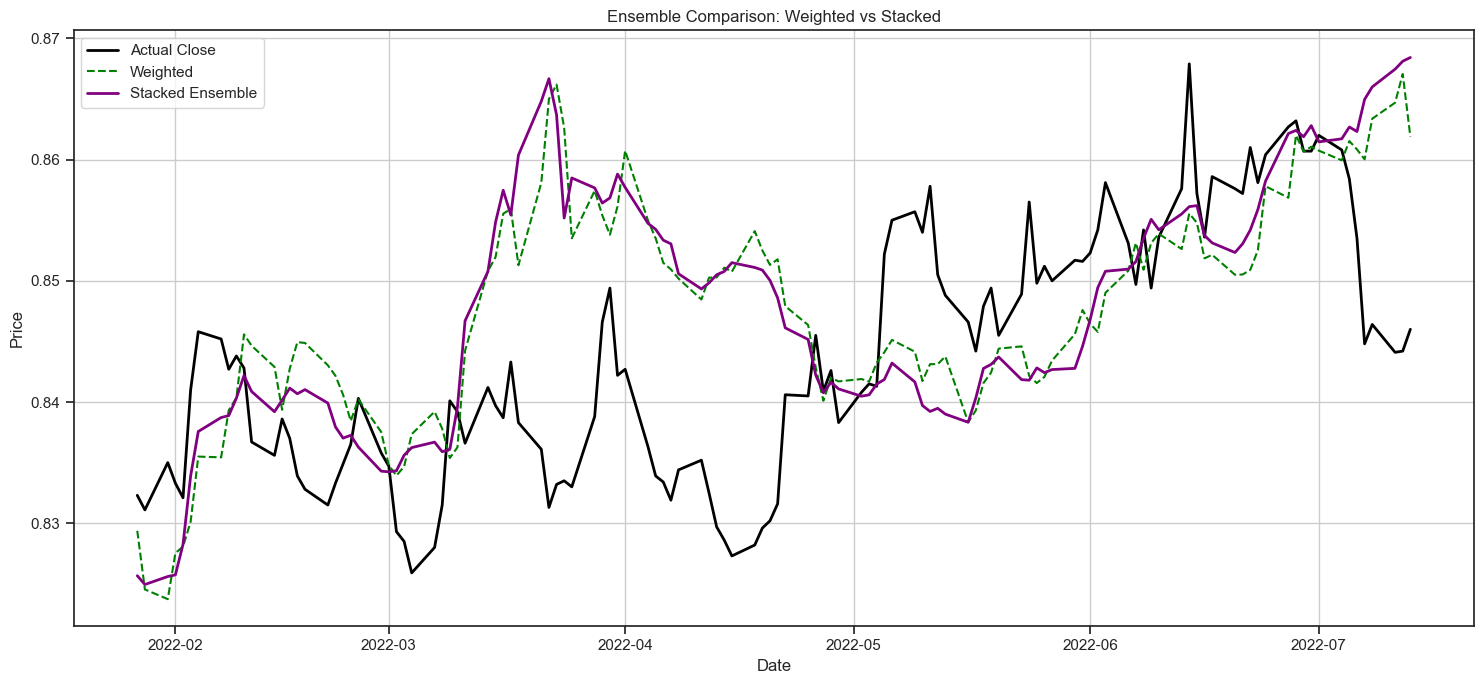

In [526]:
# === Plot: Weighted vs Stacked Ensemble ===

start_idx = len(ensemble_df) - len(meta_df)  # Align lengths if needed

plt.figure(figsize=(15, 7))

# Plot actual close prices
plt.plot(ensemble_df['Date'][start_idx:], ensemble_df['Actual_Close'][start_idx:], label='Actual Close', color='black', linewidth=2)

# Plot weighted ensemble predictions
plt.plot(ensemble_df['Date'][start_idx:], ensemble_df['Weighted Ensemble'][start_idx:], label='Weighted', linestyle='--', color='green')

# Plot stacked ensemble predictions (already aligned)
plt.plot(meta_df['Date'], meta_df['Stacked Ensemble'], label='Stacked Ensemble', color='purple', linewidth=2)

# Final plot formatting
plt.title('Ensemble Comparison: Weighted vs Stacked')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [527]:
# CROSS VAL FOR META AND CHECK FOR OVERFITTING

In [528]:
from sklearn.model_selection import cross_val_score, KFold

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [529]:
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === Define CV Strategy ===
cv = TimeSeriesSplit(n_splits=5)

# === Cross-Validate Final Meta-Model (Already Trained Above) ===
cv_rmse = -cross_val_score(meta_model, stack_X_train, stack_y_train, cv=cv, scoring='neg_root_mean_squared_error')
cv_mae = -cross_val_score(meta_model, stack_X_train, stack_y_train, cv=cv, scoring='neg_mean_absolute_error')
cv_r2 = cross_val_score(meta_model, stack_X_train, stack_y_train, cv=cv, scoring='r2')

print("📊 Final Meta-Model Cross-Validation Results:")
print(f"  ▸ CV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
print(f"  ▸ CV MAE : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}")
print(f"  ▸ CV R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")


📊 Final Meta-Model Cross-Validation Results:
  ▸ CV RMSE: 0.0034 ± 0.0019
  ▸ CV MAE : 0.0028 ± 0.0019
  ▸ CV R²  : 0.6020 ± 0.4787


In [530]:

# === Make Predictions on Training and Testing Data ===
y_train_pred = meta_model.predict(stack_X_train)  # Predict on training set
y_test_pred = meta_model.predict(stack_X_test)    # Predict on test set

# === Trim Predictions and Targets to Match Shortest Length (min_len) ===
# Ensures fair comparison when evaluating models that operate on different sequence lengths
y_train_trim = y_train[-len(y_train_pred):]  
y_test_trim = y_test[-len(y_test_pred):]    


# === Evaluate Train Performance ===
print("📊 Train Performance (Trimmed):")
evaluate_model("Meta Model Train Data", y_train_trim, y_train_pred)
# Assesses how well the model fits the training data

# === Evaluate Test Performance ===
print("\n📊 Test Performance (Trimmed):")
evaluate_model("Meta Model Test Data", y_test_trim, y_test_pred)
# Evaluates generalization to unseen test datalevel0_train_preds, X_train_level0])
#stack_X_test  = np.hstack([level0_test_preds, X_test_level0])

📊 Train Performance (Trimmed):
Meta Model Train Data Evaluation:
MAE:  0.0229
RMSE: 0.0276
R²:   -0.2551


📊 Test Performance (Trimmed):
Meta Model Test Data Evaluation:
MAE:  0.0018
RMSE: 0.0024
R²:   0.9775



In [531]:
print(f"stack_X_train.shape = {stack_X_train.shape}")
print(f"y_train_pred.shape  = {y_train_pred.shape}")
print(f"y_train_trim.shape  = {y_train_trim.shape}")


stack_X_train.shape = (724, 58)
y_train_pred.shape  = (724,)
y_train_trim.shape  = (724,)


In [532]:
rf_meta_q10 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_meta_q10.fit(stack_X_train_q10, stack_y_train)

RandomForestRegressor(random_state=42)

In [533]:
rf_meta_q90 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_meta_q90.fit(stack_X_train_q90, stack_y_train)

RandomForestRegressor(random_state=42)

In [534]:
y_pred = rf_meta.predict(stack_X_train)

In [535]:
# === Calculate Prediction Gaps (Residuals) ===

predicted = y_pred   # Model predictions on test data
expected = y_test         # Actual values from test set
gap = []                  # List to store residuals

# Loop through predictions and actual values
for p, e in zip(predicted, expected):
    # Compute the difference (residual) between expected and predicted values
    # This shows how far off each prediction was from the true value
    gap.append(e - float(p))  # Cast p to float in case it's a NumPy type

In [536]:
# === Analyze Residual Extremes ===

print(max(gap))  
# Prints the largest positive residual (biggest underprediction)

print(abs(min(gap)))  
# Prints the absolute value of the largest negative residual (biggest overprediction)

0.017787500000000844
0.032042900000000096


In [537]:
import os
import joblib

# Ensure models directory exists
os.makedirs("models", exist_ok=True)

# === Raw & Preprocessed Data ===
joblib.dump(df, "models/original_df.pkl")
joblib.dump((X_train, X_test, y_train, y_test), "models/data_split.pkl")

# === Base Models ===
# ARIMA
joblib.dump(arima_model, "models/arima_model.pkl")

# Prophet
joblib.dump(prophet, "models/prophet_model.pkl")

# === Meta-Models (Standard) ===
joblib.dump(meta_model, "models/meta_model_ridge.pkl")
joblib.dump(lasso_meta, "models/meta_model_lasso.pkl")
joblib.dump(rf_meta, "models/meta_model_rf.pkl")
# === Quantile-Specific Meta-Models ===
joblib.dump(rf_meta_q10, "models/meta_model_rf10.pkl")
joblib.dump(rf_meta_q90, "models/meta_model_rf90.pkl")
joblib.dump(gb_meta, "models/meta_model_gb.pkl")

# === Ensemble Forecast Results ===
joblib.dump(ensemble_df, "models/ensemble_results_df.pkl")

['models/ensemble_results_df.pkl']

In [538]:
# Predicting Future Outcome

In [539]:
# === Prepare Latest 2 Weeks Data for Prediction ===
df_last_2weeks_x = df_last_2weeks.drop(columns=['Date', 'target_regression', 'target_classification'])
# Drop non-feature columns (date and targets) to get feature matrix for prediction

vv = 'target_regression'  # Specify which target variable to evaluate

In [540]:
df_last_2weeks.shape

(12, 58)

In [541]:
df_last_2weeks_x.shape[0] == level0_preds.shape[0]

False

In [542]:
expected = df_last_2weeks[vv].values

predicted_q10 = rf_meta.predict( np.hstack([level0_preds_10[-len(df_last_2weeks_x):], df_last_2weeks_x[-min_len:]]) )
predicted_q50 = rf_meta.predict( np.hstack([level0_preds[-len(df_last_2weeks_x):], df_last_2weeks_x[-min_len:]]) )
predicted_q90 = rf_meta.predict( np.hstack([level0_preds_90[-len(df_last_2weeks_x):], df_last_2weeks_x[-min_len:]]) )

In [543]:
for p, e in zip(predicted_q50, expected):
    # Compute the difference (residual) between expected and predicted values
    # This shows how far off each prediction was from the true value
    print(f"⏱ Expected: {e:.5f} |  {p:.5f}]")

⏱ Expected: 0.86516 |  0.86036]
⏱ Expected: 0.86091 |  0.86381]
⏱ Expected: 0.86307 |  0.86319]
⏱ Expected: 0.86333 |  0.86319]
⏱ Expected: 0.86002 |  0.86360]
⏱ Expected: 0.86262 |  0.86310]
⏱ Expected: 0.86244 |  0.86391]
⏱ Expected: 0.86170 |  0.86393]
⏱ Expected: 0.86624 |  0.86390]
⏱ Expected: 0.86653 |  0.86425]
⏱ Expected: 0.86853 |  0.86521]
⏱ Expected: 0.86705 |  0.86737]


In [544]:
# === Actual Target Values ===
expected = df_last_2weeks[vv].values

# === Display and Store Gaps ===
gap = []
for lower, median, upper, actual in zip(predicted_q10, predicted_q50, predicted_q90, expected):
    print(f"⏱ Expected: {actual:.5f} | Median: {median:.5f} | CI: [{lower:.5f}, {upper:.5f}]")
    gap.append(actual - median)


⏱ Expected: 0.86516 | Median: 0.86036 | CI: [0.85935, 0.86122]
⏱ Expected: 0.86091 | Median: 0.86381 | CI: [0.86344, 0.86492]
⏱ Expected: 0.86307 | Median: 0.86319 | CI: [0.86314, 0.86499]
⏱ Expected: 0.86333 | Median: 0.86319 | CI: [0.86293, 0.86409]
⏱ Expected: 0.86002 | Median: 0.86360 | CI: [0.86340, 0.86431]
⏱ Expected: 0.86262 | Median: 0.86310 | CI: [0.86297, 0.86510]
⏱ Expected: 0.86244 | Median: 0.86391 | CI: [0.86362, 0.86457]
⏱ Expected: 0.86170 | Median: 0.86393 | CI: [0.86348, 0.86448]
⏱ Expected: 0.86624 | Median: 0.86390 | CI: [0.86351, 0.86448]
⏱ Expected: 0.86653 | Median: 0.86425 | CI: [0.86465, 0.86475]
⏱ Expected: 0.86853 | Median: 0.86521 | CI: [0.86541, 0.86538]
⏱ Expected: 0.86705 | Median: 0.86737 | CI: [0.86714, 0.86738]


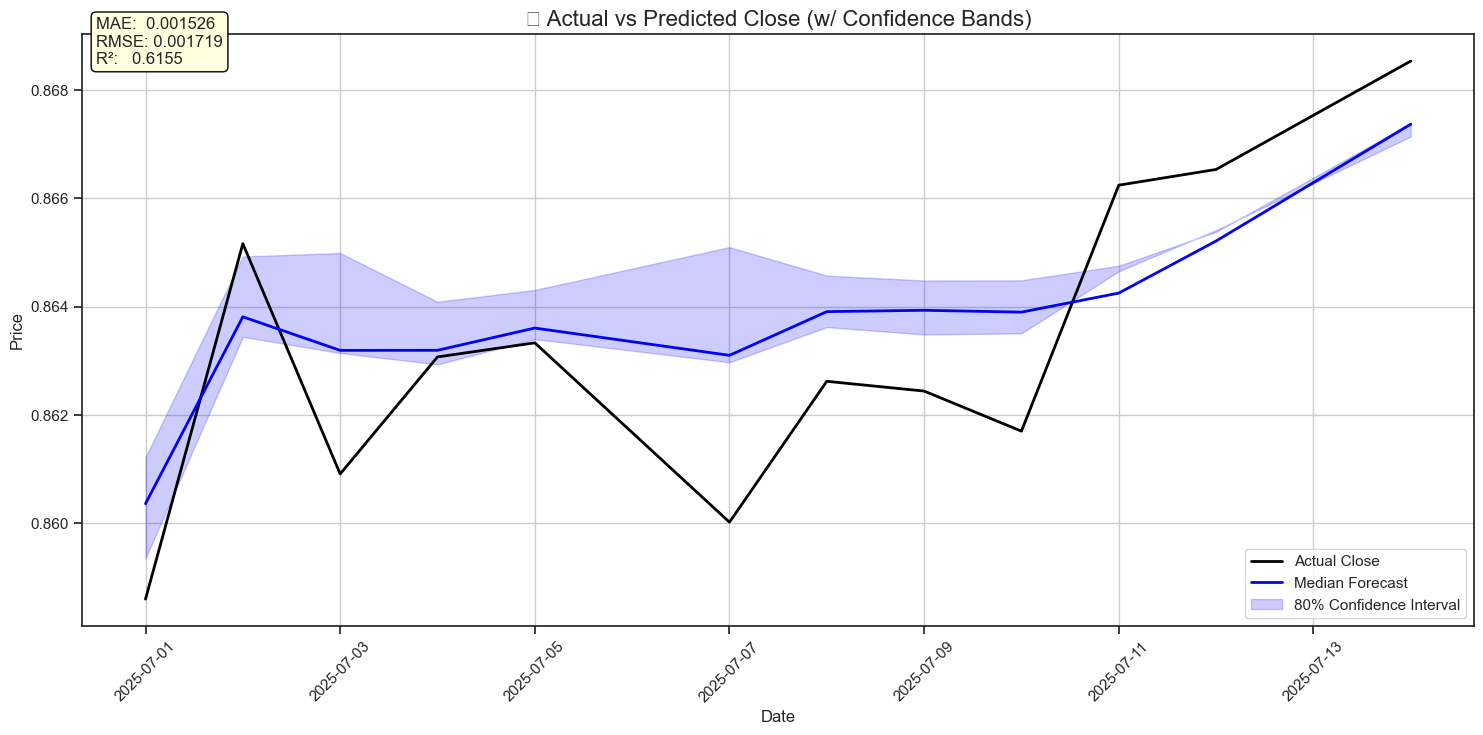

In [545]:
# === Calculate Evaluation Metrics ===
mae = mean_absolute_error(df_last_2weeks['Close'], predicted_q50)
# MAE: average of the absolute differences between actual and predicted values

rmse = np.sqrt(mean_squared_error(df_last_2weeks['Close'], predicted_q50))
# RMSE: square root of average squared error — penalizes larger errors more than MAE

r2 = r2_score(df_last_2weeks['Close'], predicted_q50)
# R²: proportion of variance explained by the model (1.0 = perfect, 0 = baseline)

# === Plot Actual vs Predicted Prices ===
plt.figure(figsize=(15, 7))

# Actual prices
plt.plot(df_last_2weeks['Date'], df_last_2weeks['Close'],
         label='Actual Close', color='black', linewidth=2)

# Median prediction
plt.plot(df_last_2weeks['Date'], predicted_q50,
         label='Median Forecast', color='blue', linewidth=2)

# Confidence Interval (shaded region between q10 and q90)
plt.fill_between(df_last_2weeks['Date'], predicted_q10, predicted_q90,
                 color='blue', alpha=0.2, label='80% Confidence Interval')

# Annotations
plt.text(
    0.01, 0.95,
    f'MAE:  {mae:.6f}\nRMSE: {rmse:.6f}\nR²:   {r2:.4f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="black")
)

# Styling
plt.title('📈 Actual vs Predicted Close (w/ Confidence Bands)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


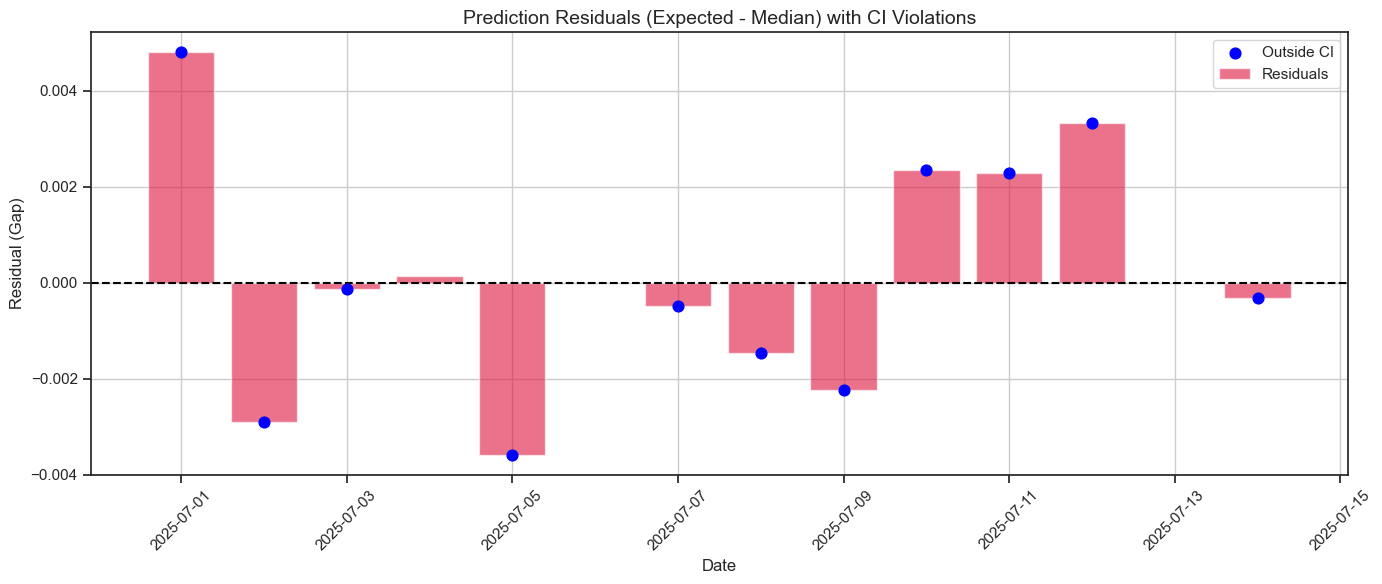

In [573]:
# === Compute Residuals ===
gap = [e - float(m) for e, m in zip(expected, predicted_q50)]

# === Check for Confidence Interval Violations ===
violations = [
    not (low <= actual <= high)
    for actual, low, high in zip(expected, predicted_q10, predicted_q90)
]

# === Define X-Axis Labels ===
labels = df_last_2weeks['Date'][-len(gap):] if 'Date' in df_last_2weeks.columns else range(len(gap))

# === Plot ===
plt.figure(figsize=(14, 6))

bars = plt.bar(labels, gap, color='crimson', alpha=0.6, label='Residuals')
plt.axhline(0, color='black', linestyle='--')

# === Highlight Violations ===
for i, (label, v) in enumerate(zip(labels, violations)):
    if v:
        plt.scatter(label, gap[i], color='blue', s=60, zorder=5, label='Outside CI' if i == 0 else "")

# === Styling ===
plt.title("Prediction Residuals (Expected - Median) with CI Violations", fontsize=14)
plt.xlabel("Date" if isinstance(labels[0], (str, pd.Timestamp)) else "Index")
plt.ylabel("Residual (Gap)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [574]:
# FORECAST

In [581]:
# === Clone Full Historical Data ===
history = df.sort_values("Date").copy().reset_index(drop=True)
# Make a sorted, clean copy of the dataset to simulate live feature updates without altering the original

# === Storage for Future Predictions ===
future_preds = []
# Initialize an empty list to collect predictions over simulated steps

# === Feature Engineering Function for Recursive Predictions ===
def compute_features(df):
    df = df.copy()
    df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    df.dropna(inplace=True)

    # === Candle Features ===
    df['Candle_Size'] = (df['Close'] - df['Open']).abs()
    df['Range'] = (df['High'] - df['Low']).replace(0, 1e-6)
    df['Upper_Wick_Ratio'] = (df['High'] - df[['Open', 'Close']].max(axis=1)) / df['Range']
    df['Lower_Wick_Ratio'] = (df[['Open', 'Close']].min(axis=1) - df['Low']) / df['Range']
    df['Body_to_Range'] = (df['Open'] - df['Close']).abs() / df['Range']
    df.drop(columns=['Range'], inplace=True)

    # Time features
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['is_week_start'] = (df['dayofweek'] == 0).astype(int)
    df['is_week_end'] = (df['dayofweek'] == 4).astype(int)

    # Log Return
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

    # Technical Indicators
    close = df['Close']
    high = df['High']
    low = df['Low']

    df['RSI'] = RSIIndicator(close, window=14).rsi()
    macd = MACD(close)
    df['MACD'] = macd.macd()
    df['MACD_signal'] = macd.macd_signal()
    df['MACD_diff'] = macd.macd_diff()

    bb = BollingerBands(close)
    df['BB_upper'] = bb.bollinger_hband()
    df['BB_lower'] = bb.bollinger_lband()
    df['BB_width'] = df['BB_upper'] - df['BB_lower']

    df['SMA_10'] = SMAIndicator(close, window=10).sma_indicator()
    df['SMA_20'] = SMAIndicator(close, window=20).sma_indicator()
    df['SMA_50'] = SMAIndicator(close, window=50).sma_indicator()
    df['SMA_100'] = SMAIndicator(close, window=100).sma_indicator()

    df['ATR'] = AverageTrueRange(high, low, close, window=3).average_true_range()

    # Lag & Return Features
    df['lag_1'] = close.shift(1)
    df['lag_2'] = close.shift(2)
    df['lag_3'] = close.shift(3)
    df['return_1d'] = close.pct_change(periods=1) * 100

    # Rolling Features
    df['sma_5'] = close.rolling(5).mean()
    df['sma_10'] = close.rolling(10).mean()
    df['sma_21'] = close.rolling(21).mean()
    df['volatility_10'] = close.rolling(10).std()
    df['volatility_21'] = close.rolling(21).std()

    # Price Action
    high_body = df[['Open', 'Close']].max(axis=1)
    low_body = df[['Open', 'Close']].min(axis=1)
    df['upper_shadow'] = df['High'] - high_body
    df['lower_shadow'] = low_body - df['Low']

    # Targets
    df['target_regression'] = df['Close'].shift(-1)
    df['target_classification'] = (df['Close'].shift(-1) > df['Close']).astype(int)

    # Candle Shape
    df['body'] = (df['Close'] - df['Open']).abs()
    df['range'] = df['High'] - df['Low']

    df['is_doji'] = (df['body'] / df['range'] < 0.1).astype(int)
    df['is_hammer'] = ((df['lower_shadow'] > 2 * df['body']) & (df['upper_shadow'] < 0.1 * df['body'])).astype(int)
    df['is_inverted_hammer'] = ((df['upper_shadow'] > 2 * df['body']) & (df['lower_shadow'] < 0.1 * df['body'])).astype(int)

    # Momentum & ROC
    df['momentum_3'] = df['Close'] - df['Close'].shift(3)
    df['momentum_7'] = df['Close'] - df['Close'].shift(7)
    df['roc_3'] = df['Close'].pct_change(periods=3)
    df['roc_7'] = df['Close'].pct_change(periods=7)
    df['vol_5'] = df['Close'].rolling(5).std()
    df['vol_10'] = df['Close'].rolling(10).std()
    df['sma_5_slope'] = df['sma_5'].diff()

    # Engulfing Patterns
    df['prev_close'] = df['Close'].shift(1)
    df['prev_open'] = df['Open'].shift(1)
    df['is_bullish_engulfing'] = (
        (df['prev_close'] > df['prev_open']) &
        (df['Close'] > df['Open']) &
        (df['Open'] < df['prev_close']) &
        (df['Close'] > df['prev_open'])
    ).astype(int)
    df['is_bearish_engulfing'] = (
        (df['prev_open'] > df['prev_close']) &
        (df['Close'] < df['Open']) &
        (df['Open'] > df['prev_close']) &
        (df['Close'] < df['prev_open'])
    ).astype(int)

    # Trend Flags
    df['price_above_sma20'] = (df['Close'] > df['SMA_20']).astype(int)
    df['price_above_sma50'] = (df['Close'] > df['SMA_50']).astype(int)
    df['sma_crossover'] = (df['SMA_20'] > df['SMA_50']).astype(int)
    df['log_return_positive'] = (df['Log_Return'] > 0).astype(int)

    df.drop(columns=['prev_open', 'prev_close'], inplace=True)
    df.ffill(inplace=True)
    df.dropna(inplace=True)

    return df


In [586]:
features = df_train_fe.drop(columns=['Date', 'target_regression', 'target_classification'])

In [587]:
def prepare_lstm_live_input(history, feature_cols, timesteps=10):
    """
    Prepares the last `timesteps` rows of `history` for LSTM prediction.
    Returns a 3D array: (1, timesteps, features)
    """
    lstm_window = history[feature_cols].tail(timesteps).copy()
    lstm_window.fillna(0, inplace=True)

    if lstm_window.shape[0] < timesteps:
        raise ValueError(f"Not enough data for LSTM input. Expected {timesteps} rows, got {lstm_window.shape[0]}")

    return lstm_window.values.reshape(1, timesteps, -1)

In [588]:
# === Step 1: Initialize Forecast Context ===
history = df.sort_values("Date").copy().reset_index(drop=True)
# Make a clean, sorted copy of historical data to simulate forward updates
future_preds = []  # Store forecast results

# === Step 2: Walk Forward Over Next 7 Days ===
for i in range(7):
    next_date = history.iloc[-1]['Date'] + pd.Timedelta(days=1)  # Forecast date
    last_row = history.iloc[-1]  # Most recent row for reference

    # Estimate market volatility using ATR (or fallback to 1% of last close)
    atr = history.iloc[-2].get('ATR', np.nan)
    if pd.isna(atr):
        atr = last_row['Close'] * 0.01
    high_noise = np.random.uniform(0.3, 1.0) * atr
    low_noise = np.random.uniform(0.3, 1.0) * atr

    # === Step 3: Create Simulated Row for Next Day ===
    new_row = {
        'Date': next_date,
        'Open': last_row['Close'],  # Opening price = previous close
        'Close': np.nan,            # Placeholder — will be updated by model
        'High': last_row['Close'] + high_noise,
        'Low': last_row['Close'] - low_noise,
        'Volume': last_row['Volume'],  # Hold volume constant (can be randomized later)
    }

    # === Step 4: Append and Recompute Features ===
    history = pd.concat([history, pd.DataFrame([new_row])], ignore_index=True)

    # Recalculate indicators using only the tail for efficiency
    tail_window = 100
    tail = compute_features(history.tail(tail_window).copy())

    tail.fillna(method='ffill', inplace=True)  # Forward-fill for stability
    tail.fillna(0, inplace=True)               # Backfill any remaining nulls

    # Inject updated feature values into full history
    history.update(tail)

    # === Step 5: Make Prediction for Next Day ===
    X_next = history.iloc[[-1]].reindex(columns=features.columns, fill_value=0)
    X_next = X_next.fillna(0)  # Force all NaNs to 0

# Just in case any expected column is completely missing (rare, but happens)
for col in features.columns:
    if col not in X_next.columns:
        X_next[col] = 0

    X_next = X_next[features.columns]  # Ensure correct column order
    # Prophet expects 'ds' column and optionally regressors if used during training
    prophet_input = pd.DataFrame({
        'ds': [next_date]
    })
    
    # Add regressors if used
    for reg in usable_regressors:
        if reg in X_next.columns:
            prophet_input[reg] = X_next[reg].values[0]
    
    # Prophet prediction
    p_pred_df = prophet.predict(prophet_input)
    p_pred = p_pred_df['yhat'].values  # Get the predicted mean

    l_pred = model.predict(X_next)
    xg_preg = xgb_q50.predict(X_next)
    stack_X_train = np.hstack([p_pred,l_pred,xg_preg, X_next]) 

    y_next = meta_model.predict(X_next)[0]  # Predict next closing price
    history.at[history.index[-1], 'Close'] = y_next  # Assign prediction to Close

    # Store forecast
    future_preds.append((next_date, y_next))

# === Step 6: Output Predictions ===
for date, pred in future_preds:
    print(f"📅 {date.date()} → 🔮 Predicted Close: {pred:.5f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1

In [589]:
X_next

,Open,High,Low,Close,Volume,Candle_Size,Upper_Wick_Ratio,Lower_Wick_Ratio,Body_to_Range,dayofweek,...,roc_7,vol_5,vol_10,sma_5_slope,is_bullish_engulfing,is_bearish_engulfing,price_above_sma20,price_above_sma50,sma_crossover,log_return_positive
4877,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


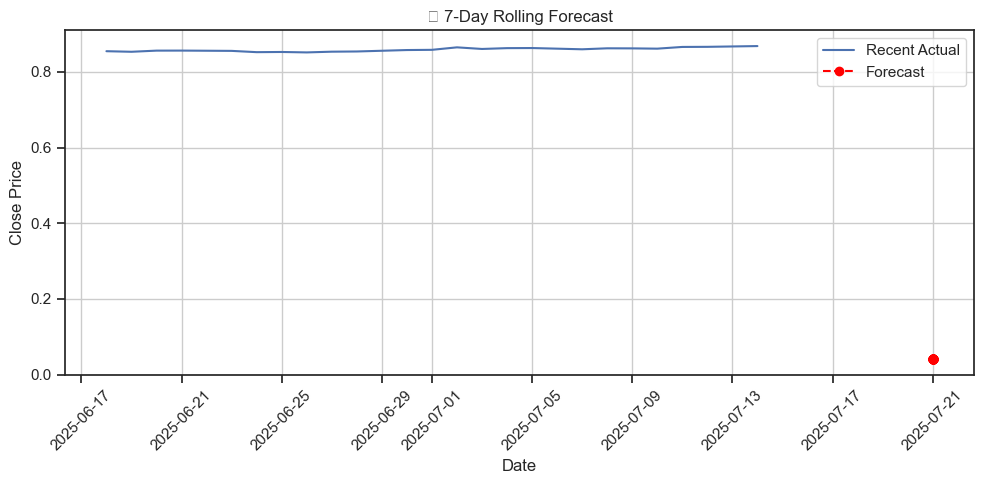

In [590]:
# === Convert Predictions to DataFrame ===
forecast_df = pd.DataFrame(future_preds, columns=["Date", "Predicted_Close"])
# Structure the list of (date, prediction) into a tidy DataFrame

# === Plot the Forecast vs Recent Actuals ===
plt.figure(figsize=(10, 5))  # Canvas size

# Plot the most recent actual 30 days from history
plt.plot(history['Date'][-30:], history['Close'][-30:], label='Recent Actual')

# Overlay forecasted next 7 days
plt.plot(forecast_df['Date'], forecast_df['Predicted_Close'],
         marker='o', linestyle='--', color='red', label='Forecast')

# === Chart Decoration ===
plt.title("📉 7-Day Rolling Forecast")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)  # Better date formatting
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()  # Render the chart

In [ ]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'notebook'  # Set Plotly to display inline

# === Prepare Recent Historical Data ===
recent_data = history[-30:].copy()  # Last 30 days for candlesticks

# Initialize interactive Plotly figure
fig = go.Figure()

# === Candlestick Trace (Actual Prices) ===
fig.add_trace(go.Candlestick(
    x=recent_data['Date'],
    open=recent_data['Open'],
    high=recent_data['High'],
    low=recent_data['Low'],
    close=recent_data['Close'],
    name="Recent Actual"
))

# === Line Forecast (Future Predicted Close) ===
forecast_df = pd.DataFrame(future_preds, columns=["Date", "Predicted_Close"])

fig.add_trace(go.Scatter(
    x=forecast_df["Date"],
    y=forecast_df["Predicted_Close"],
    mode='lines+markers',
    name='7-Day Forecast',
    line=dict(color='orange', dash='dash'),
    marker=dict(size=6),
    hovertemplate='📅 %{x|%Y-%m-%d}<br>🔮 Forecast: %{y:.5f}<extra></extra>'
))

# === Final Layout and Style ===
fig.update_layout(
    title="📉 7-Day Rolling Forecast (Candlestick + Prediction)",
    xaxis_title="Date",
    yaxis_title="Close Price",
    xaxis_rangeslider_visible=False,  # Hide range slider
    hovermode="x unified",  # Shared hover across traces
    template="plotly_white",
    height=500
)

fig.show()

In [ ]:
forecast_df.to_csv("7_day_forecast.csv", index=False)